# Machine Learning Project - 2025/26

Ana Rita Dias 20250480<br>
Catarina Santos 20250501<br>
Marisa Ramos 20250521<br>
Nadia Scaletchi 20250404

# Table of content

* [1. Importing Libraries](#1.-Importing-Libraries)
* [2. Importing the data](#2.-Importing-the-data)
* [3. Exploring the data](#3.-Exploring-the-data)
    * [3.1 Applying the `.head()` and `.tail()` method](#3.1-Applying-the-`.head()`-and-`.tail()`-method)
    * [3.2 Applying the `.info()` method](#3.2-Applying-the-`.info()`-method)
    * [3.3 Checking for NaN values](#3.3-Checking-for-NaN-values)
    * [3.4 Identifying incorrect values in the columns of the dataset](#3.4-Identifying-incorrect-values-in-the-columns-of-the-dataset)
    * [3.5 Checking for duplicate values](#3.5-Checking-for-duplicate-values)
    * [3.6. Non metric features](#3.6-Non-metric-features)
* [4. Data Preparation](#4.-Data-Preparation)
    * [4.1 Missing values](#4.1-Missing.-values)
        * [4.1.1 Missing values - Numerical features](#4.1.1-Missing-values---Numerical-features)
        * [4.1.2 Missing values - Categorical features](#4.1.2-Missing-values---Categorical-features)
    * [4.2 Outliers: Check and pre-process](#4.2-Outliers:-Check-and-pre-process)
    * [4.3 Categorical features](#4.3-Categorical-features)
        * [4.3.1 Variable `Brand`](#4.3.1-Variable-`Brand`)
        * [4.3.2 Variable `model`](#4.3.2-Variable-`model`)
        * [4.3.3 Variable `transmission`](#4.3.3-Variable-`transmission`)
        * [4.3.4 Variable `fuelType`](#4.3.4-Variable-`fuelType`)
    * [4.4 Encoding](#4.4-Encoding)
    * [4.5 Features review](#4.5-Features-review)
    * [4.6 Creating new Features](#4.6-Creating-new-Features)
    * [4.7 Data Scalling](#4.7-Data-Scalling)
* [5. Feature Selection](#5.-Feature-Selection)
    * [5.1 Filter methods](#5.1-Filter-methods)
        * [5.1.1 Univariate variables](#5.1.1-Univariate-variables)
        * [5.1.2 Correlation indices](#5.1.2-Correlation-indices)
        * [5.1.3 Chi-Square for categorical data](#5.1.3-Chi-Square-for-categorical-data)
    * [5.2 Wrapper Methods](#5.2-Wrapper-Methods)
        * [5.2.1 RFE](#5.2.1-RFE)
    * [5.3 Embedded Methods](#5.3-Embedded-Methods)
        * [5.3.1 Lasso Regression](#5.3.1-Lasso-Regression)
    * [5.4 Final Insights](#5.4-Final-Insights)
        * [5.4.1 Numerical Data](#5.4.1-Numerical-Data)
        * [5.4.2 Categorical Data](#5.4.2-Categorical-Data)
* [6. Model Selection](#6.-Model-Selection)
    * [6.1 Testing models - removing 3 numerical features](#6.1-Testing-models---removing-3-numerical-features)
    * [6.2 Testing models - removing 2 numerical features](#6.2-Testing-models---removing-2-numerical-features)
    * [6.3 Testing Models - removing (other) 2 numerical features](#6.3-Testing-Models---removing-(other)-2-numerical-features)
* [7. Conclusions - Best Model](#7.-Conclusions---Best-Model)
* [8. Test Prediction and creation of a CSV file](#8.-Test-Prediction-and-criation-of-a-CSV-file)
* [9. Data Extraction](#9.-Data-Extraction)

__Project workflow__

This notebook documents our rationale and code for each step of the machine learning pipeline process. Our work is structured as follows:

1. Exploratory Data Analysis (EDA): We start by importing the train.csv and test.csv datasets and carrying out a detailed analysis to understand the data structure. Using methods such as `.head()`, `.info()` and `.describe()`, we assess the distribution of variables and identify critical data quality issues. The aim of this phase is to detect duplicates, verify data types and flag inconsistencies such as negative `mileage` or `tax` values and typographical errors in categorical labels for example correcting __mercede__ to __Mercedes__.

2. Data preparation: To ensure high data quality, we implement a preprocessing regimen. Missing values are handled based on distribution: the median is imputed for skewed numerical features, and the mean is imputed for features with normal distributions. Categorical gaps are filled with __Unknown__. Inconsistent categorical entries are standardized and One-Hot Encoding is applied to transform them into a machine readable format. Additionally, we perform feature engineering to derive new predictive variables, such as `carAge` and `AvgMileagePerYear`, before normalizing all numerical data using __MinMaxScaler__ to optimize algorithm convergence.

3. Feature selection: We use a multifaceted selection strategy to identify the most predictive features and reduce dimensionality. Our approach integrates filter methods (such as removing zero-variance variables and analyzing Spearman correlation), wrapper methods (such as utilizing recursive feature elimination) and embedded methods (such as leveraging lasso regression to penalize non-informative coefficients).
4. Model selection: We build and evaluate a diverse set of regression algorithms, including linear regression and random forest, to select the architecture that yields the most accurate price predictions on the test set. Using a 70/30 training/validation split, we assess the performance of the models using robust metrics, specifically mean squared error (__MSE__), mean absolute error (__MAE__) and the score, to select the architecture that yields the most accurate price predictions on the test set.

## 1. Importing Libraries

In [5]:
#pip install pandas

In [6]:
# Data Handling Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical and Feature Selection Tools
from scipy.stats import chi2_contingency  # Chi-squared test
from sklearn.feature_selection import mutual_info_classif  # Mutual information for classification

#simple preprocessing of datasets
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import PredefinedSplit

# Expressive type hints
from typing import List, Optional

# Warnings
import warnings

warnings.filterwarnings('ignore')

#to correct syntax
import difflib

#filter methods
# spearman 
import scipy.stats as stats
from joblib import Parallel, delayed

#wrapper methods
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# embedded methods
from sklearn.linear_model import LassoCV

np.random.seed(33)  # For reproducibility

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## 2. Importing the Data

Using the `.shape()` method, we can visualize how many rows and columns has our datasets.<br>
<br>
The `display.max_columns` option controls how many columns are printed. Setting the option to `None` causes Pandas to display all columns in the DataFrame.

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
# Loading the data
train_data = pd.read_csv('../Group_28/project_data/train.csv', sep=',')
test_data = pd.read_csv('../Group_28/project_data/test.csv', sep=',')

In [9]:
print('The train dataset has', train_data.shape[0], 'rows and', train_data.shape[1], 'columns.')
print('The test dataset has', test_data.shape[0], 'rows and', test_data.shape[1], 'columns.')

The train dataset has 75973 rows and 14 columns.
The test dataset has 32567 rows and 13 columns.


The output above shows that the train dataset has 75973 rows and 14 columns. However, the test dataset has 32567 rows and 13 columns, 1 column fewer than in the train dataset. This might suggest that the additional column in the train set isn't relevant for the prediction (may represent the target variable).

## 3. Exploring the Data

This table gives information of the variables and their description.
| **Attribute**  | **Description**  |
| --------- | ------------- |
`carID` | An attribute that contains an identifier for each car.
`Brand`  |  The car’s main brand (e.g. Ford, Toyota)
`model`  | The car model
`year`  | The year of Registration of the Car
`mileage`  | The total reported distance travelled by the car (in miles)
`tax`  | The amount of road tax (in £) that, in 2020, was applicable to the car in question.
`fuelType`  | Type of Fuel used by the car (Diesel, Petrol, Hybrid, Electric)
`mpg`  | Average Miles per Gallon
`engineSize`  | Size of Engine in liters (Cubic Decimeters)
`paintQuality%`  | The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation).
`previousOwners`  | Number of previous registered owners of the vehicle.
`hasDamage`  | Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.
`price`  | The car’s price when purchased by Cars 4 You (in £).
`transmission` | Indicates the type of transmission in the vehicle.

### 3.1 Applying the `.head()` and `.tail()` method


The method `.head()` is used to take a first look at the data, displaying the first five rows of every feature in the train dataset.

In [10]:
train_data.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


The method `.tail()` is used to take a first look at the data, displaying the last five rows of every feature in the  train dataset.

In [11]:
train_data.tail()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.3,2.0,78.0,0.0,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.9,2.0,38.0,2.0,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.0,1.0,57.0,3.0,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.1,2.0,74.0,2.0,0.0
75972,15795,Ford,Fiesta,2018.0,10495,Manual,16709.0,Petro,145.0,64.2,1.1,38.0,1.0,0.0


These two methods made it possible to view the first and last five rows, respectively. This information can be used to draw important conclusions about the data, such as:

* The variable `carID` can be set as an index, using the method `set_index()` from pandas;

* There are missing values on the data;

* There are different types of data, such as:

    * `Categorical` -> Nominal;<br>
    * `Numerical` -> Discrete and Continuous

### 3.2 Applying the `.info()` method

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


After analyzing the segment above, we can see that there are features whose type doesn't correspond to the meaning of the feature, for example:

* The feature `year` is a __float__, which doesn't make sense as this feature corresponds to the year the car was registered. It isn't correct to have a non-integer year;

* The feature `previousOwners` is a __float__, which also does not make sense for the same reason as in the previous variable, because there are no non-integer values for humans;

* Initially, we were told that the variable `hasDamage` was a __boolean__, but when we used the `.info()` method, the variable became a __float__. This is because the __boolean__ type cannot store NaN (NaN is a __float__ value by default). When Pandas processes a column that should be __boolean__ but detects at least one NaN, it corrects the type to __float__.

### 3.3 Checking for __NaN__ values

In [13]:
train_data.replace("", np.nan, inplace=True)
train_data.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

The output above shows that two of the 14 features have no NaN values and rest of the features have a lot of missing values.

In [14]:
print(f'There are {train_data[train_data['Brand'].isna()].shape[0]} rows with missing values in the `Brand` feature, which corresponds to {round((train_data['Brand'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1521 rows with missing values in the `Brand` feature, which corresponds to 2.0% of the entire dataset.


In [15]:
print(f'There are {train_data[train_data['model'].isna()].shape[0]} rows with missing values in the `model` feature, which corresponds to {round((train_data['model'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1517 rows with missing values in the `model` feature, which corresponds to 2.0% of the entire dataset.


In [16]:
print(f'There are {train_data[train_data['year'].isna()].shape[0]} rows with missing values in the `year` feature, which corresponds to {round((train_data['year'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1491 rows with missing values in the `year` feature, which corresponds to 1.96% of the entire dataset.


In [17]:
print(f'There are {train_data[train_data['transmission'].isna()].shape[0]} rows with missing values in the `transmission` feature, which corresponds to {round((train_data['transmission'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1522 rows with missing values in the `transmission` feature, which corresponds to 2.0% of the entire dataset.


In [18]:
print(f'There are {train_data[train_data['mileage'].isna()].shape[0]} rows with missing values in the `mileage` feature, which corresponds to {round((train_data['mileage'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1463 rows with missing values in the `mileage` feature, which corresponds to 1.93% of the entire dataset.


In [19]:
print(f'There are {train_data[train_data['fuelType'].isna()].shape[0]} rows with missing values in the `fuelType` feature, which corresponds to {round((train_data['fuelType'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')

There are 1511 rows with missing values in the `fuelType` feature, which corresponds to 1.99% of the entire dataset.


In [20]:
print(f'There are {train_data[train_data['tax'].isna()].shape[0]} rows with missing values in the `tax` feature, which corresponds to {round((train_data['tax'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 7904 rows with missing values in the `tax` feature, which corresponds to 10.4% of the entire dataset.


In [21]:
print(f'There are {train_data[train_data['mpg'].isna()].shape[0]} rows with missing values in the `mpg` feature, which corresponds to {round((train_data['mpg'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 7926 rows with missing values in the `mpg` feature, which corresponds to 10.43% of the entire dataset.


In [22]:
print(f'There are {train_data[train_data['engineSize'].isna()].shape[0]} rows with missing values in the `engineSize` feature, which corresponds to {round((train_data['engineSize'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1516 rows with missing values in the `engineSize` feature, which corresponds to 2.0% of the entire dataset.


In [23]:
print(f'There are {train_data[train_data['paintQuality%'].isna()].shape[0]} rows with missing values in the `paintQuality%` feature, which corresponds to {round((train_data['paintQuality%'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1524 rows with missing values in the `paintQuality%` feature, which corresponds to 2.01% of the entire dataset.


In [24]:
print(f'There are {train_data[train_data['previousOwners'].isna()].shape[0]} rows with missing values in the `previousOwners%` feature, which corresponds to {round((train_data['previousOwners'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1550 rows with missing values in the `previousOwners%` feature, which corresponds to 2.04% of the entire dataset.


In [25]:
print(f'There are {train_data[train_data['hasDamage'].isna()].shape[0]} rows with missing values in the `hasDamage` feature, which corresponds to {round((train_data['hasDamage'].isna().sum() / len(train_data)) * 100, 2)}% of the entire dataset.')


There are 1548 rows with missing values in the `hasDamage` feature, which corresponds to 2.04% of the entire dataset.


### 3.4 Identifying incorrect values in the columns of the dataset

We will use the `.describe()` method so we can check if the features has any incorrect values.

In [26]:
train_data.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


As can be seen above, there are some features with incorrect values, such as:

* In the `car ID` feature, the presence of a value ID equal to 0 may indicate a placeholder or missing value, so this should be verified for consistency;

* In the `year` feature, several inconsistencies were identified. Some values are not integers which is incorrect because a car’s registration year must be a whole number. Additionally, although the scope of the dataset ends in 2020, the records extend up to 2024. These entries are likely to be clerical errors or noise, and will be dealt with during the data cleaning phase;

* In the `mileage` feature, some of the values are negative, which is incorrect because there are no negative distances;

* The same thing happens with the `tax` features as happened with the `mileage` features. It doesn't make sense to have negative values for this tax because it represents the amount of road tax (in £) applicable to the car in question in 2020;

* The `mpg` feature has the same problem as the previous two: it doesn't make sense to have negative values for "miles per gallon";

* The `engineSize` feature contains negative values, which is incorrect because an engine cannot have a negative size;

* In the `paintQuality%` feature, the maximum value exceeds 100%, which also makes no sense because the percentage only go up to 100%;

* In the `previousOwner` feature, there are two problems:
    * It has floating-point values, which makes no sense because this feature indicates the number of people who have owned the car before;
    * It has negative values, which also don't make sense because it represents a number of people.


### 3.5 Checking for duplicate values

#### Duplicates values in the `carID` feature

In [27]:
duplicates = train_data.duplicated().sum()
print(f"There are", duplicates, "duplicated entries in the train dataset")

There are 0 duplicated entries in the train dataset


In [28]:
duplicates_carID = train_data['carID'].duplicated().sum()
print(f"There are", duplicates_carID, "duplicated entries in the 'carID' column")

There are 0 duplicated entries in the 'carID' column


This means that each car ID is unique and functions as an identifier for its respective car. Therefore, each train line represents a single car.


### 3.6. Non metric features

In this section, we will check for inconsistencies in non metric features.

In [29]:
brand = train_data['Brand'].unique()
brand

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

In [30]:
model = train_data['model'].unique()
model

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [31]:
fueltype = train_data['fuelType'].unique()
fueltype

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

As can be seen, the three categorical variables have a single inconsistency in common:

* In the `Brand` feature, there are several assignments but many of them are just errors, such as ‘__Mercedes__’ and “__mercede__”. This leads us to believe that it is the same car brand, but with an error, and the same happens with other brands.

* In the `model` feature, happens exactly the same thing: there are several assignments but many of them are just errors, such as ‘__GOLF__’ and “__Golf__.” This suggests that it is the same car model but with different spelling, and the same happens with other models;

* Finally, the `fuelType` feature has the same type of problems as the previous two. For example, the types ‘__Petrol__’ and “__Petro__” suggest that they are the same type, but with errors.

We can conclude that it will be necessary to process these features, so that we can analyse better their relationships and correlation with other features. This will be done later.

## 4. Data Preparation

In [32]:
test_data_real = test_data['carID']

In [33]:
train_data_indexed = train_data.set_index('carID')
test_data_indexed = test_data.set_index('carID')


In [34]:
X = train_data_indexed.drop(['price'], axis=1)
y = train_data_indexed['price']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=32567)

### 4.1 Missing values

As previously checked, there are missing values in almost every variable, except for the variables `CardID` and `Price`. <br>
These missing values do not make sense in the context of the dataset. So, we will need to check whether dropping them would significantly reduce the size of the dataset.

In [35]:
total_rows = len(X_train)
rows_after_dropping_na = len(X_train.dropna())
rows_removed = total_rows - rows_after_dropping_na
percent_removed = (rows_removed / total_rows) * 100
percent_removed

28.369154397247137

If we drop the missing values, we would lose approximately 28.3% of the data, which is significant. Therefore, we should consider other methods to handle the missing values, such as replacing them with the __mean__, __median__ or __mode__, depending on the variable type and distribution.

#### 4.1.1 Missing values - Numerical features

First, we will take care of the missing values of numerical variables. <br>
For the numerical variables, the missing values can be filled with the __mean__ or the __median__. So, to decide between this two options, we will search for the existence of __outliers__.

In [36]:
numeric_NA = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']
#check for the outliers in the numeric_NA variables
q1 = X_train[numeric_NA].quantile(0.25)
q3 = X_train[numeric_NA].quantile(0.75) 
iqr = q3 - q1
outliers = ((X_train[numeric_NA] < (q1 - 1.5 * iqr)) | (X_train[numeric_NA] > (q3 + 1.5 * iqr))).sum()
outliers

year               1236
mileage            2542
tax               14218
mpg                 828
engineSize          521
paintQuality%         0
previousOwners      505
hasDamage             0
dtype: int64

The only features without __outliers__ are the `paintQuality%` and `hasDamage`. For this two features it is safe to fill the missing values with the __mean__ because then it is not be affected by __outliers__. For the other numerical features, we will fill the missing values with the __median__.



In [37]:
paint_mean = X_train['paintQuality%'].mean()
damage_mean = X_train['hasDamage'].mean()


X_train['paintQuality%'].fillna(paint_mean, inplace=True)
X_train['hasDamage'].fillna(damage_mean, inplace=True)  

X_val['paintQuality%'].fillna(paint_mean, inplace=True)
X_val['hasDamage'].fillna(damage_mean, inplace=True)    

test_data_indexed['paintQuality%'].fillna(paint_mean, inplace=True)
test_data_indexed['hasDamage'].fillna(damage_mean, inplace=True) 

In [38]:
median_replace = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners']
for col in median_replace:
    X_train[col].fillna(X_train[col].median(), inplace=True)
    X_val[col].fillna(X_train[col].median(), inplace=True)
    test_data_indexed[col].fillna(X_train[col].median(), inplace=True)

Checking if the missing values of the numeric values were corrected filled.

In [39]:
X_train.isna().sum()

Brand             1033
model             1056
year                 0
transmission      1072
mileage              0
fuelType          1073
tax                  0
mpg                  0
engineSize           0
paintQuality%        0
previousOwners       0
hasDamage            0
dtype: int64

In [40]:
X_val.isna().sum()

Brand             488
model             461
year                0
transmission      450
mileage             0
fuelType          438
tax                 0
mpg                 0
engineSize          0
paintQuality%       0
previousOwners      0
hasDamage           0
dtype: int64

In [41]:
test_data_indexed.isna().sum()

Brand             649
model             650
year                0
transmission      623
mileage             0
fuelType          656
tax                 0
mpg                 0
engineSize          0
paintQuality%       0
previousOwners      0
hasDamage           0
dtype: int64

#### 4.1.2 Missing values - Categorical features

Next, we will see if the categoric missing values are still a significant part of the dataset.

In [42]:
total_rows = len(X_train)
rows_after_dropping_na = len(X_train.dropna())
rows_removed = total_rows - rows_after_dropping_na
percent_removed = (rows_removed / total_rows) * 100
percent_removed

7.709520317406593

The missing values of the categorical variables are still a significant part of the dataset, more than 5%. For that reason, we will fill them with `Unknown`.

In [43]:
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']
for col in categorical_features:
    X_train[col].fillna('Unknown', inplace=True)
    X_val[col].fillna('Unknown', inplace=True)
    test_data_indexed[col].fillna('Unknown', inplace=True)

Checking if the missing values of the categorical values were corrected filled.

In [44]:
X_train.isna().sum()

Brand             0
model             0
year              0
transmission      0
mileage           0
fuelType          0
tax               0
mpg               0
engineSize        0
paintQuality%     0
previousOwners    0
hasDamage         0
dtype: int64

In [45]:
X_val.isna().sum()

Brand             0
model             0
year              0
transmission      0
mileage           0
fuelType          0
tax               0
mpg               0
engineSize        0
paintQuality%     0
previousOwners    0
hasDamage         0
dtype: int64

In [46]:
test_data_indexed.isna().sum()

Brand             0
model             0
year              0
transmission      0
mileage           0
fuelType          0
tax               0
mpg               0
engineSize        0
paintQuality%     0
previousOwners    0
hasDamage         0
dtype: int64

### 4.2 Outliers: Check and pre-process

First, we will check for the __outliers__ in the numeric variables.

In [47]:
numeric_only = X_train.select_dtypes(include=[np.number])
q1 = numeric_only.quantile(0.25)
q3 = numeric_only.quantile(0.75)
iqr = q3 - q1
outliers = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr))).sum()
outliers

year               1236
mileage            2672
tax               14218
mpg                1211
engineSize          521
paintQuality%         0
previousOwners      505
hasDamage             0
dtype: int64

And the __boxplots__...

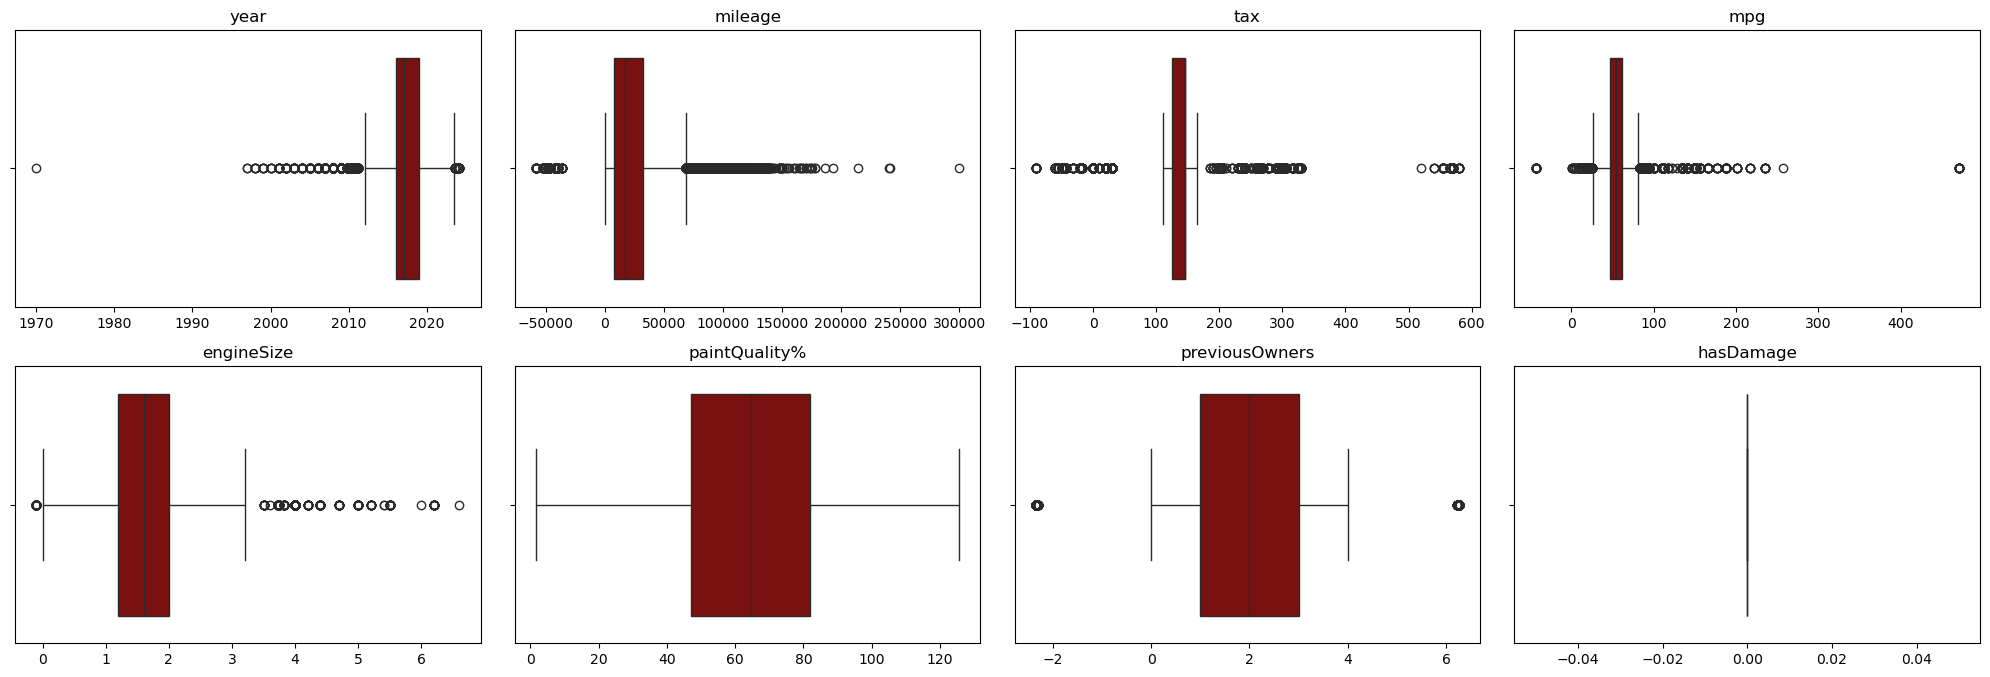

In [48]:
#boxplot for all numeric variables
num_cols = 4
num_rows = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_only):
    sns.boxplot(data=X_train, x=col, ax=axes[i], color='darkred')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The plots clearly show outliers in impossible ranges, which confirms the data quality issues we found in our notebook:

* Negative Values: `mileage`, `tax`, `mpg`, `engineSize` and `previousOwners` all display data points below zero, which are not physically possible.

* Invalid Percentages: `paintQuality%` shows outliers above 100, which is also an error.

Many of the key features are not normally distributed, which justifies our preprocessing choices:

* Right-Skew: The boxplots for mileage, and year are very compact, with long tails of outliers on the high end (or low end for year).

The presence of so many outliers in key predictors like price and mileage supports your decision to use Capping rather than removing them, as deletion would cause significant data loss.

The heavy skew and outliers in features like `mileage`, `tax`, and `engineSize` also confirm your choice to impute missing values using the median instead of the mean.

The boxplot for `hasDamage` is just a single line at 0.

In [49]:
outlier_mask = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr)))
outlier_rows = outlier_mask.any(axis=1)
num_outlier_rows = outlier_rows.sum()

print(f"The presence of outliers is {(num_outlier_rows/len(train_data))*100:.2f}% of the dataset.")

The presence of outliers is 22.49% of the dataset.


The presence of __outliers__ is high (22.49%), so if removed too much data would be lost. To solve the big amount of outliers problem, we applied the `Capping (Winsorizing)` method. This method limits extreme values (outliers) in a dataset to a specified percentile range (in this case, 0.01 and 0.99 quantiles).

In [50]:
for col in numeric_only:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower,upper)

    if col in X_val.columns:
        X_val[col] = X_val[col].clip(lower=lower, upper=upper)
    
    if col in test_data.columns:
        test_data_indexed[col] = test_data_indexed[col].clip(lower=lower, upper=upper)

### 4.3 Categorical features

We felt the need to clean and standardize the categorical names, to avoid causing miss understandings or errors with the following code. For that reason, we used the functions `.strip()` to remove spaces in the beginning  and end, and `.lower()` to set all of the letters to lowercase.

In [51]:
#Removes extra spaces and makes capitalization consistent
for col in ['Brand', 'model', 'transmission', 'fuelType']:
    X_train[col] = X_train[col].str.strip().str.lower()
    X_val[col] = X_val[col].str.strip().str.lower()
    test_data_indexed[col] = test_data_indexed[col].str.strip().str.lower()

#### 4.3.1 Variable `Brand`

Even after the standardization, it is necessary to verify the syntax errors in categories and their frequency to implement an improve.

In [52]:
X_train['Brand'].value_counts()

Brand
ford        10766
mercedes     7822
vw           7014
opel         6248
audi         5001
bmw          4998
toyota       3101
skoda        2899
hyundai      2248
unknown      1033
ord           228
for           221
ercedes       159
mercede       154
w             151
v             135
pel           125
ope           122
aud           108
mw            107
bm            100
udi            92
oyota          69
skod           63
koda           61
toyot          50
yundai         43
hyunda         43
or              6
ercede          6
pe              3
yunda           2
kod             2
ud              1
Name: count, dtype: int64

##### Syntax errors

It is possible to observe that there are several errors in the syntax, like for example `oyota` instead of `toyota`. <br>
To solve this, some names will be replaced to their corrected form and the others will be assigned to the designation `unknown`.


The replacement of the feature `Brand` of the cars was based on the `model` of the cars. For that we used the method `.unique()` to check if each model belonged to the same brand, as shown in the following example. Then, we created a dictionary to replace all the errors to their correct forms.

In [53]:
model_W = X_train.loc[X_train['Brand'] == 'w', 'model']
model_W.unique()

array(['golf', 'passat', 'polo', 't-roc', 'up', 'tiguan', 't-cross', 'u',
       'golf sv', 'touareg', 'gol', 'arteon', 'california', 'unknown',
       'caravelle', 'touran', 'sharan', 'cc', 'scirocco', 't-cros'],
      dtype=object)

In [54]:
model_v = X_train.loc[X_train['Brand'] == 'v', 'model']
model_v.unique()

array(['t-cross', 'tiguan', 'sharan', 'caravelle', 'polo', 'up', 'golf',
       't-roc', 'pol', 'touareg', 'unknown', 'scirocco', 'beetle',
       'touran', 'passat', 'amarok', 'arteon', 't-ro'], dtype=object)

In [55]:
brand_cleanup_map = {
    'ford' : 'ford',        
    'mercedes' : 'mercedes',     
    'vw' : 'volkswagen',           
    'opel': 'opel',         
    'audi' : 'audi',         
    'bmw' : 'bmw',          
    'toyota' : 'toyota',       
    'skoda' : 'skoda',        
    'hyundai' : 'hyundai',      
    'unknown' : 'unknown',      
    'ord' : 'ford',           
    'for' : 'ford',           
    'ercedes' : 'mercedes',       
    'mercede' : 'mercedes',       
    'w' : 'volkswagen',             
    'v' : 'volkswagen',             
    'pel' : 'opel',           
    'ope' : 'opel',           
    'aud' : 'audi',           
    'mw' : 'bmw',            
    'bm' : 'bmw',            
    'udi' : 'audi',            
    'oyota' : 'toyota',          
    'skod' : 'skoda',           
    'koda' : 'skoda',           
    'toyot' : 'toyota',          
    'hyunda' : 'hyundai',         
    'yundai' : 'hyundai',         
    'or' : 'ford',              
    'ercede' : 'mercedes',          
    'pe' : 'opel',              
    'yunda' : 'hyundai',           
    'kod' : 'skoda',             
    'ud' : 'audi',
    'oyot' : 'toyota',
    'm' : 'bmw'              
}


# Apply the SAME map to ALL datasets
# This ensures consistency and prevents data leakage accusations
X_train['Brand']   = X_train['Brand'].replace(brand_cleanup_map)
X_val['Brand']     = X_val['Brand'].replace(brand_cleanup_map)
test_data_indexed['Brand'] = test_data_indexed['Brand'].replace(brand_cleanup_map)

Checking if all the values are correct now...

In [56]:
X_train['Brand'].value_counts()

Brand
ford          11221
mercedes       8141
volkswagen     7300
opel           6498
bmw            5205
audi           5202
toyota         3220
skoda          3025
hyundai        2336
unknown        1033
Name: count, dtype: int64

In [57]:
X_val['Brand'].value_counts()

Brand
ford          4842
mercedes      3533
volkswagen    3085
opel          2854
bmw           2187
audi          2123
toyota        1402
skoda         1278
hyundai       1000
unknown        488
Name: count, dtype: int64

In [58]:
test_data_indexed['Brand'].value_counts()


Brand
ford          6888
mercedes      5004
volkswagen    4466
opel          4008
bmw           3174
audi          3130
toyota        1982
skoda         1839
hyundai       1427
unknown        649
Name: count, dtype: int64

#### 4.3.2 Variable `model`

For the variable `model`, the method will be the same to check the inconsistencies.

In [59]:
X_train['model'].value_counts()

model
focus      4738
c class    3599
fiesta     3072
golf       2283
corsa      1609
           ... 
beetl         1
yet           1
fox           1
s clas        1
z             1
Name: count, Length: 284, dtype: int64

##### Syntax errors

As we had noticed before, it is possible to observe that there are several errors in the syntax. <br>
To solve this, some names will be replaced to their corrected form and the others will be assigned to the designation to the `unknown`.<br>
A manual list was created for that purpose, with the help of the method `.unique()` and with all the correct models of this dataset. Then, we crated a function to replace all the syntax errors with their corrected form with the help of the python library `diflib`.


In [60]:
X_train['model'].unique()

array(['corsa', 'yeti outdoor', 'golf', 'octavia', 'a3', 'fiesta', 'a1',
       'polo', 'c class', 'mokka x', 'astra', 'focus', 'i30', 'auris',
       'unknown', 'a class', 'ecosport', 'aygo', 'q7', 'tt', 's-max',
       'q5', 'e class', 'yaris', 'tucson', 'q2', 'slk', 'grandland x',
       'i10', 't-cross', 'scala', '4 series', 'sl class', 'tiguan',
       '3 series', 'combo life', 'ka+', 'c-max', 'a5', 'amarok', 'kuga',
       'prius', 'mokka', 'a4', '1 series', 'grand tourneo connect',
       'passat', 'karoq', '5 series', 'viva', 'fabia', 'corolla',
       '7 series', 'cl class', 'glc class', 'avensis', 'up', 'x1', 'yari',
       'gle class', 'q3', 'c-hr', 'touran', 'ioniq', 's class', 'gol',
       'grand c-max', 'a6', 'rav4', '2 series', 't-roc', 'arteon', 'auri',
       'q', 'insignia', 'b class', 'gls class', 'crossland x', 'i800',
       'ampera', 'rapid', 'citigo', 'kodiaq', 'mustang', 'mondeo',
       'zafira', 'rs3', 'gtc', 'kona', 'x5', 'v clas', 'ix35',
       'caravelle'

In [61]:
correct_models = [
    'fiesta', 'focus', 'ka', 'ka+', 'ecosport', 'b-max', 's-max',
    'mondeo', 'kuga', 'tourneo connect', 'grand tourneo connect', 'tourneo custom',
    'c-max', 'grand c-max', 'galaxy', 'edge', 'fusion', 'mustang',
    'puma', 'ranger', 'escort', 'streetka',
    'a class', 'b class', 'c class', 'cla class', 'cls class', 'e class', 'sl class',
    'slk', 'clk', 'clc class', 'g class', 'gl class', 'gla class', 'glb class',
    'glc class', 'gle class', 'gls class', 'm class', 'v class', 'cl class',
    '200', '220', '230', 'x-class', 'golf', 'passat', 'polo', 'up', 'sharan', 'tiguan',
    't-roc', 'arteon', 'touran', 'caddy', 'caddy life', 'caddy maxi', 'caddy maxi life',
    'beetle', 'shuttle', 'caravelle', 'touareg', 't-cross', 'california', 'scirocco',
    'amarok', 'cc', 'eos', 'fox',
    'insignia', 'mokka', 'corsa', 'astra', 'viva', 'adam',
    'crossland x', 'zafira', 'zafira tourer', 'grandland x', 'combo life',
    'gtc', 'meriva', 'agila', 'antara', 'tigra', 'vivaro',
    'cascada', 'vectra', 'ampera', '1 series', '2 series', '3 series', '4 series', '5 series', '6 series', '7 series', '8 series',
    'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7',
    'z3', 'z4',
    'm2', 'm3', 'm4', 'm5', 'm6',
    'i3', 'i8','a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8',
    'q2', 'q3', 'q5', 'q7', 'q8',
    's3', 's4', 's5', 's8',
    'rs3', 'rs4', 'rs5', 'rs6',
    'tt', 'r8',
    'sq5', 'sq7','yaris', 'c-hr', 'aygo', 'auris', 'rav4', 'prius', 'corolla',
    'verso', 'gt86', 'land cruiser', 'proace verso', 'hilux', 'avensis',
    'camry', 'supra', 'iq', 'urban cruiser','octavia', 'fabia', 'rapid', 'yeti', 'scala', 'kamiq',
    'kodiaq', 'karoq', 'citigo', 'roomster', 'superb','i10', 'i20', 'i30', 'i40', 'i800', 'ioniq',
    'tucson', 'kona', 'santa fe', 'veloster', 'getz',
    'ix20', 'ix35', 'accent', 'terracan', 'yeti outdoor', 'tiguan allspace', 'jetta','unknown', 'kadjar'
]
def correct_model(name):
    
    if not isinstance(name, str):
        return name
    
    match = difflib.get_close_matches(name, correct_models, n=1, cutoff=0.6)
    return match[0] if match else name

X_train['model'] = X_train['model'].apply(correct_model)
X_val['model'] = X_val['model'].apply(correct_model)
test_data_indexed['model'] = test_data_indexed['model'].apply(correct_model)

Checking if all the values are correct now...

In [62]:
X_train.loc[X_train['Brand'] == 'mercedes', 'model'].unique()

array(['c class', 'a class', 'e class', 'slk', 'sl class', 'cl class',
       'glc class', 'gle class', 'b class', 'gls class', 'v class',
       'gla class', 'unknown', 'm class', 'x-class', 'cls class',
       'gl class', 'cla class', 'g class', 'glb class', 'clk',
       'clc class', '220', '230', '200'], dtype=object)

In [63]:
X_val.loc[X_val['Brand'] == 'mercedes', 'model'].unique()

array(['c class', 'unknown', 'a class', 'e class', 'glc class',
       'cla class', 'gle class', 'cl class', 'cls class', 'b class',
       'v class', 'gla class', 'slk', 'sl class', 'gl class', 'm class',
       'gls class', 'x-class', 'g class', 'clk', 'glb class'],
      dtype=object)

In [64]:
test_data_indexed.loc[test_data_indexed['Brand'] == 'mercedes', 'model'].unique()

array(['b class', 'c class', 'm class', 'e class', 'a class', 'x-class',
       'v class', 'sl class', 'gla class', 'cls class', 'glc class',
       'cl class', 'gl class', 'gle class', 'unknown', 'cla class',
       'g class', 'slk', 'glb class', 'gls class', 'i10', 'clk',
       'clc class'], dtype=object)

The method `.groupby` was used to validate whether there were any mistakes, specifically whether there were any `model` categories with more than one `Brand`.

In [65]:
train= X_train[X_train['Brand'] != 'unknown']
t=train.groupby('model')['Brand'].nunique()
t=t[t>1]
t

model
i3         2
iq         2
ka         2
unknown    9
Name: Brand, dtype: int64

Since there are more than one brand associated with these three models, we addressed this issue by researching and identifying the correct way to complete the model names, ensuring the dataset remains accurate and consistent. We also noticed that the `model` 'ka' is associated with two brands, which is correct, since there are two brands with the name 'ka' in their models. Regarding the `unknowm` values, it would be not appropriate to correct them in this context.

In [66]:
X_train.loc[X_train['model'] == 'i3', 'Brand']

carID
13430        bmw
33505    hyundai
12786    unknown
9737         bmw
9815         bmw
12332        bmw
12853        bmw
34188    hyundai
10653        bmw
12090        bmw
10695        bmw
12640        bmw
11532        bmw
8497         bmw
32106    hyundai
33844    hyundai
9196         bmw
13075        bmw
12269        bmw
11962        bmw
32063    hyundai
11589        bmw
10967        bmw
Name: Brand, dtype: object

Logical reasoning was applied in the examples below. For instance, in the first case, the two 'i3' entries form `bmw` and `hyundai` were identified as 'i3' and 'i30', respectively (these are the actually models of the cars, confirmed through research).

In [67]:
X_train.loc[(X_train['Brand']=='hyundai')&(X_train['model']=='i3'),'model'] = 'i30'
X_train.loc[(X_train['Brand']=='bmw')&(X_train['model']=='iq'),'model'] = 'i3'
X_train.loc[(X_train['model']=='ka'),'Brand'] = 'ford'

X_val.loc[(X_val['Brand']=='hyundai')&(X_val['model']=='i3'),'model'] = 'i30'
X_val.loc[(X_val['Brand']=='bmw')&(X_val['model']=='iq'),'model'] = 'i3'
X_val.loc[(X_val['model']=='ka'),'Brand'] = 'ford'

test_data_indexed.loc[(test_data_indexed['Brand']=='hyundai')&(test_data_indexed['model']=='i3'),'model'] = 'i30'
test_data_indexed.loc[(test_data_indexed['Brand']=='bmw')&(test_data_indexed['model']=='iq'),'model'] = 'i3'
test_data_indexed.loc[(test_data_indexed['model']=='ka'),'Brand'] = 'ford'

It was detected that some `unknown` values in the `Brand`. This ones could be updated with the uses of their `model`. For that, it was created a dictionary with the function `.to_dict()` conecting the `model` and the `brand` rows and associated each correctly with a lambda function.

In [68]:
X_train.loc[X_train['Brand'] == 'unknown', 'model'].unique()

array(['golf', 'q5', 'yaris', 'astra', 'i10', 'mokka', 'polo',
       'crossland x', 'focus', 'corsa', 'a8', '4 series', 'fiesta',
       'gla class', 'a6', 'octavia', 'up', 'insignia', 'tucson',
       'a class', 'b class', '5 series', 'c class', 'corolla', 'aygo',
       'x2', 't-roc', '3 series', 'e class', 'sl class', 'arteon',
       'b-max', '2 series', 'gle class', 'avensis', 'ecosport', 'i30',
       'tiguan', 'unknown', 'a4', 'fabia', 't-cross', '1 series',
       'grandland x', 'kuga', 'mondeo', 'c-hr', 'x3', 'x7', 'v class',
       'q3', 'a1', 'touareg', 'm class', 'a5', 'kodiaq', 'grand c-max',
       'viva', 'yeti outdoor', 'agila', 'sharan', 'slk', 'touran',
       'santa fe', 'i20', 'x1', 'x-class', 'passat', 'scirocco',
       'cl class', 'gl class', 'a3', 'auris', 'cc', 'meriva', 'kona',
       'q2', 'tt', 'mustang', 'superb', 'zafira', 'i3', 'cls class',
       'glb class', 'glc class', 'combo life', 'q7', 'citigo', 'rav4',
       'edge', 'rapid', 's-max', 'caravelle'

In [69]:
model_to_brand = X_train[X_train['Brand']!='unknown']\
    .drop_duplicates('model')\
        .set_index('model')['Brand'].to_dict()
        
X_train['Brand']=X_train.apply(lambda row: model_to_brand.get(row['model'],row['Brand']) if row['Brand']=='unknown'else row['Brand'],axis=1)
X_val['Brand']=X_val.apply(lambda row: model_to_brand.get(row['model'],row['Brand']) if row['Brand']=='unknown'else row['Brand'],axis=1)
test_data_indexed['Brand']=test_data_indexed.apply(lambda row: model_to_brand.get(row['model'],row['Brand']) if row['Brand']=='unknown'else row['Brand'],axis=1)

#### 4.3.3 Variable `transmission`

In [70]:
X_train['transmission'].value_counts()

transmission
manual       27968
semi-auto    11336
automatic    10224
unknown       1567
anual          554
manua          542
semi-aut       242
utomatic       238
emi-auto       238
automati       224
unknow          16
nknown          11
anua             8
emi-aut          5
utomati          4
other            3
nknow            1
Name: count, dtype: int64

##### Syntax errors

There are errors in the syntax of the categories, like for example `anual` instead of `manual`. <br>
To solve this, the wrong written names will be replaced to their corrected form and the random ones, like `other`, will be to the `unknown` category.


For that, it was created a dictionary manually, with the help of the method `.unique()`, with all the correct models of this dataset. Then, we created a function to replace all the syntax errors with their corrected form.

In [71]:
transmission_cleanup_map = {
    'manual' : 'manual',
    'semi-auto' : 'semi-auto',
    'automatic' : 'automatic',
    'unknown' : 'unknown',
    'anual' : 'manual',
    'manua' : 'manual',
    'semi-aut' : 'semi-auto',
    'emi-auto' : 'semi-auto',
    'utomatic' : 'automatic',
    'automati' : 'automatic',
    'unknow' : 'unknown',
    'nknown' : 'unknown',
    'anua' : 'manual',
    'emi-aut' : 'semi-auto',
    'utomati' : 'automatic',
    'other' : 'unknown',
    'nknow' : 'unknown'
}


# Apply the SAME map to ALL datasets
# This ensures consistency and prevents data leakage accusations
X_train['transmission'] = X_train['transmission'].replace(transmission_cleanup_map)
X_val['transmission'] = X_val['transmission'].replace(transmission_cleanup_map)
test_data_indexed['transmission'] = test_data_indexed['transmission'].replace(transmission_cleanup_map)

Checking if all the values are correct now...

In [72]:
X_train['transmission'].value_counts()

transmission
manual       29072
semi-auto    11821
automatic    10690
unknown       1598
Name: count, dtype: int64

In [73]:
X_val['transmission'].value_counts()

transmission
manual       12555
semi-auto     5051
automatic     4521
unknown        665
Name: count, dtype: int64

In [74]:
test_data_indexed['transmission'].value_counts()

transmission
manual       17889
semi-auto     7267
automatic     6440
unknown        971
Name: count, dtype: int64

#### 4.3.4 Variable `fuelType`

In [75]:
X_train['fuelType'].value_counts()

fuelType
petrol      27682
diesel      20740
hybrid       1490
unknown      1073
etrol         583
petro         574
diese         418
iesel         417
other         110
hybri          30
ybrid          28
etro           16
iese            8
othe            4
ther            4
electric        3
ybri            1
Name: count, dtype: int64

##### Syntax errors

There are some syntax errors in the categories names, such as `petro` instead of `petrol`. <br>
To address this issue, the incorrectly written names will be replaced with their proper forms. The random entries, like `othe`, will be grouped under the `unknown` category. This decision is based on the fact that these entries can not be confidently classified as belonging to any known category. Therefore, assigning them to `unknown` is more appropriate than placing them under `other`, as we simply lack sufficient information to determine their correct classification.

In [76]:
fueltype_cleanup_map = {
    'petrol' : 'petrol',      
    'diesel' : 'diesel',      
    'hybrid' : 'hybrid',      
    'unknown' : 'unknown',    
    'etrol' : 'petrol',      
    'petro': 'petrol',      
    'diese': 'diesel',      
    'iesel': 'diesel',      
    'other' : 'unknown',      
    'hybri' : 'hybrid',      
    'ybrid' : 'hybrid',      
    'etro' : 'petrol',       
    'iese' : 'diesel',       
    'ther' : 'unknown',       
    'othe' : 'unknown',       
    'electric' : 'electric',    
    'ybri' : 'hybrid'       
}

# Apply the SAME map to ALL datasets
# This ensures consistency and prevents data leakage accusations
X_train['fuelType']   = X_train['fuelType'].replace(fueltype_cleanup_map)
X_val['fuelType']     = X_val['fuelType'].replace(fueltype_cleanup_map)
test_data_indexed['fuelType'] = test_data_indexed['fuelType'].replace(fueltype_cleanup_map)

In [77]:
X_train["fuelType"].value_counts()

fuelType
petrol      28855
diesel      21583
hybrid       1549
unknown      1191
electric        3
Name: count, dtype: int64

In [78]:
X_val["fuelType"].value_counts()

fuelType
petrol      12326
diesel       9302
hybrid        676
unknown       487
electric        1
Name: count, dtype: int64

In [79]:
test_data_indexed["fuelType"].value_counts()

fuelType
petrol      17497
diesel      13395
hybrid        936
unknown       738
electric        1
Name: count, dtype: int64

#### 4.4 Encoding

Now, it is necessary to encode the model by converting the categorical data into a numerical format that machine learning algorithms can understand. The method used for this was `One-Hot Encoding`.

In [80]:
# Separate categorical and numerical columns 
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Apply ohe to categorical columns
ohe = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
encoded_array = ohe.fit_transform(X_train[categorical_cols])
encoded_cols = ohe.get_feature_names_out(categorical_cols)

# Combine numerical and encoded categorical features
X_train = pd.concat([
    X_train[numerical_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array, columns=encoded_cols)
], axis=1)
X_train

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,2015.0,17308.0,125.0,54.3,1.4,63.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2017.0,23007.0,150.0,51.4,1.2,34.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [81]:
# Apply ohe to categorical columns
encoded_array_val = ohe.transform(X_val[categorical_cols])
encoded_cols_val = ohe.get_feature_names_out(categorical_cols)

# Combine numerical and encoded categorical features
X_val = pd.concat([
    X_val[numerical_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array_val, columns=encoded_cols_val)
], axis=1)
X_val

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,2019.0,10.0,145.0,42.8,2.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016.0,13393.0,20.0,68.9,1.6,54.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [82]:
encoded_array_test = ohe.transform(test_data_indexed[categorical_cols])
encoded_cols_test = ohe.get_feature_names_out(categorical_cols)

test_data = pd.concat([
    test_data_indexed[numerical_cols].reset_index(drop=True),
    pd.DataFrame(encoded_array_test, columns=encoded_cols_test)
], axis=1)
test_data

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,2020.0,30700.0,205.0,41.5,1.6,61.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2017.0,10.0,150.0,38.2,2.0,60.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

### 4.5 Features review

Before select the variables for the potencial model, it is mandatory to review the present features for redundance or leackage.

In [83]:
X_train.describe() 

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
count,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.0,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.00000

In [84]:
X_train['year'] = [int(i) for i in X_train['year']]
X_train['previousOwners'] = [int(i) for i in X_train['previousOwners']]
X_val['year'] = [int(i) for i in X_val['year']]
X_val['previousOwners'] = [int(i) for i in X_val['previousOwners']]
test_data['year'] = [int(i) for i in test_data['year']]
test_data['previousOwners'] = [int(i) for i in test_data['previousOwners']]

The feature `year` and `previousOwners` had numbers that were not correctly due their nature.<br>
 For `year`, the numbers were in a float form, not integer like they are supposed to. <br>
 For `previousOwners` , there were floating values when they should only be positive integers only. <br>


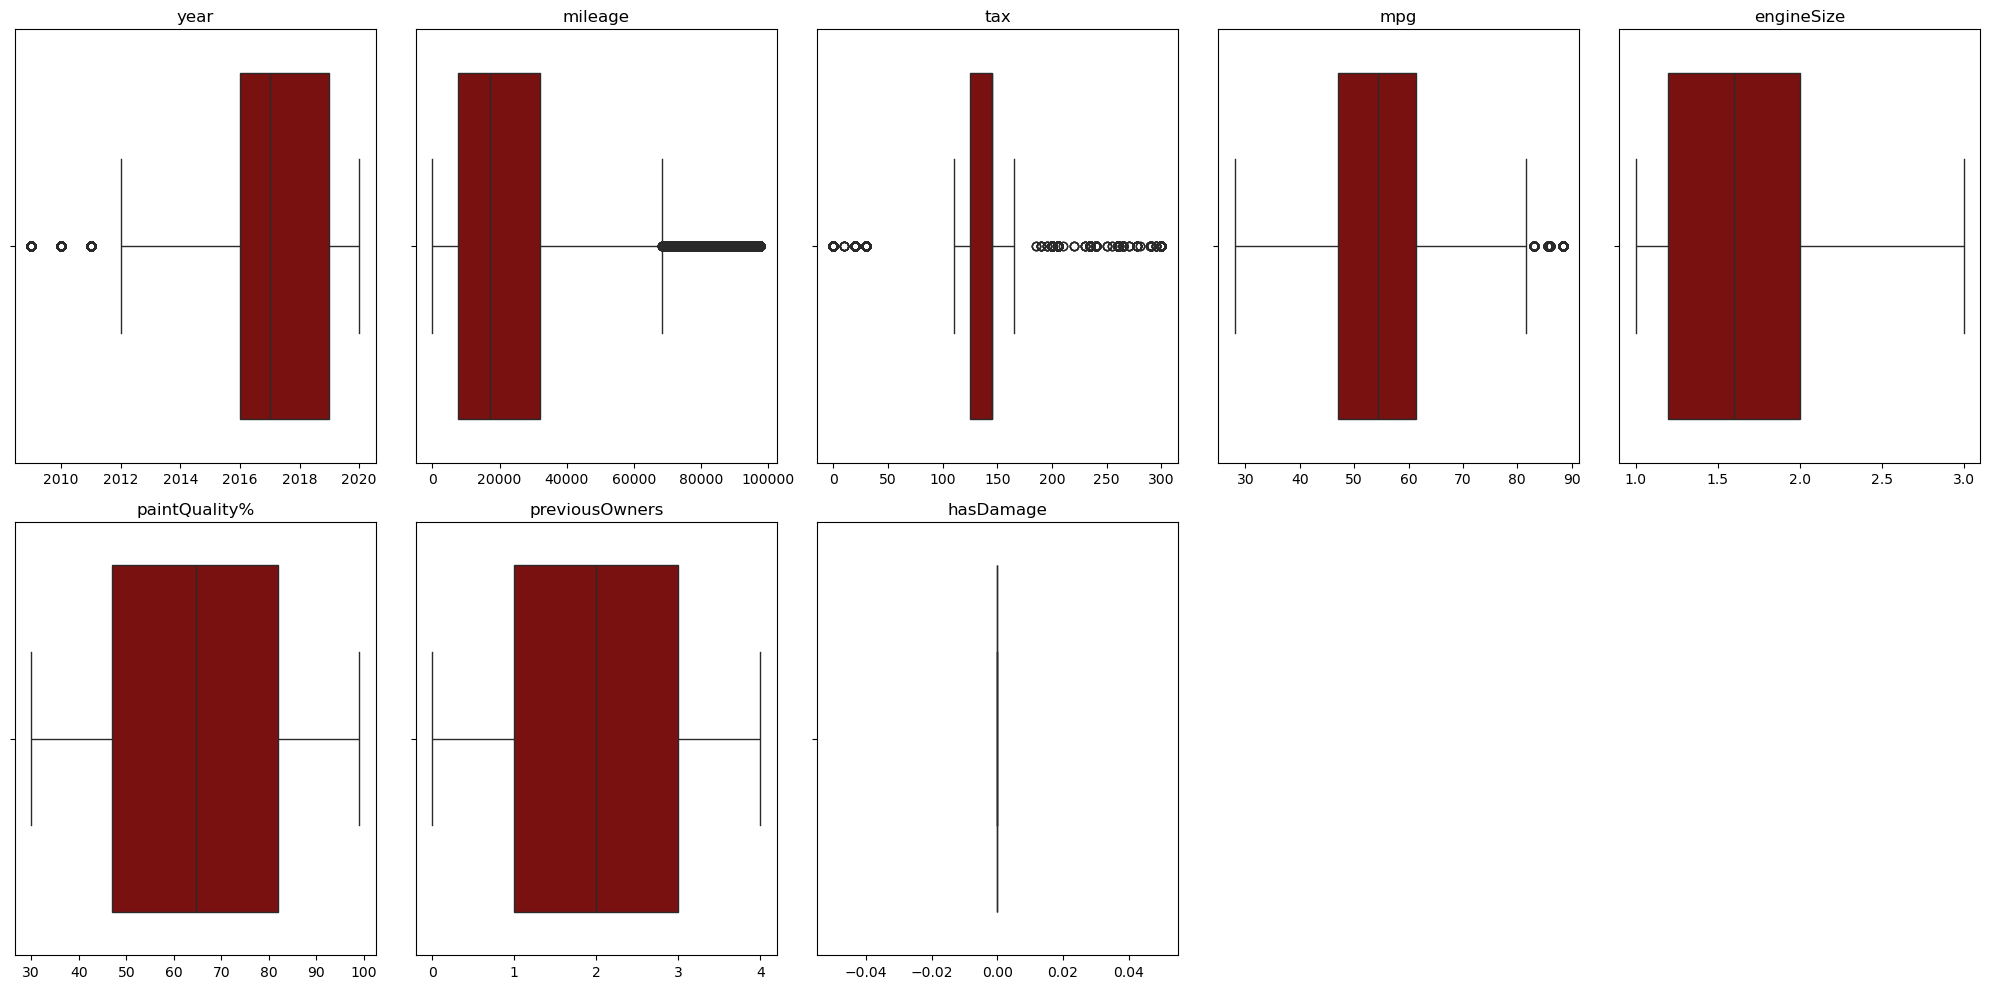

In [85]:
#boxplot for all numeric variables

numeric_cols_to_plot = [
    'year', 'mileage', 'tax',
    'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage'
]
num_cols = 5
num_rows = 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_to_plot):
    sns.boxplot(data=X_train, x=col, ax=axes[i], color='darkred')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


The most obvious change is the removal of extreme, implausible data points.

* There are no more negative values: The plots for `mileage`, `tax`, `mpg`, `engineSize` and `previousOwners` no longer show any data below zero.

* Realistic Maximums: `paintQuality%` is now correctly capped at 100 (or just below). Features like `price`, `mileage`, `tax`, and `mpg` have their "whiskers" extended to a reasonable range (`mileage` ends around 100000, not exceding 300000), and the extreme outliers beyond that are gone.

* Before the processing, `previousOwners` is now clearly distributed between 0 and 4, reflecting the integer conversion and capping performed.

The extreme values that would have heavily skewed the model's calculations have been neutralized through capping rather than deletion to avoid significant data loss. This robust approach, which includes median imputation for skewed features, will lead to more reliable model predictions.

We decided to remove the feature `hasDamage` because it has zero variance, containing only a single constant value. As a result, it provides no predictive power and contributes no useful information to the model

In [86]:
X_train.drop('hasDamage', axis=1, inplace=True)
X_val.drop('hasDamage', axis=1, inplace=True)
test_data.drop('hasDamage', axis=1, inplace=True)

### 4.6 Creating new Features

In [87]:
X_train['carAge'] = 2025 - X_train['year']
X_val['carAge'] = 2025 - X_val['year']
test_data['carAge'] = 2025 - test_data['year']

X_train['carAge'] = 2025 - X_train['carAge'].apply(lambda x:max(1, x))
X_val['carAge'] = 2025 - X_val['carAge'].apply(lambda x:max(1, x))
test_data['carAge'] = 2025 - test_data['carAge'].apply(lambda x:max(1, x))

X_train['AvgMileagePerYear'] = X_train['mileage'] / X_train['carAge']
X_val['AvgMileagePerYear'] = X_val['mileage'] / X_train['carAge']
test_data['AvgMileagePerYear'] = test_data['mileage'] / test_data['carAge']

X_train.drop('year', axis=1, inplace=True)
X_val.drop('year', axis=1, inplace=True)
test_data.drop('year', axis=1, inplace=True)

The `year` feature was transformed into the `carAge` feature.

A vehicle's price is intrinsically linked to its depreciation. While the relationship between year and price is complex, the relationship between age and price is more direct and linear for regression models.

Average Annual Mileage (`AvgMileagePerYear`): This feature was created to measure the rate at which the vehicle is used and wears down, which is an important indicator of risk and residual value.

A high total mileage on a new car (i.e. low car age) suggests intensive use and implies higher wear and tear, resulting in a lower price. Conversely, a low mileage on an old car suggests good maintenance. This feature captures the rate of wear over time.

**Note**: A small correction was applied to new cars (carAge = 0) to prevent division by zero. We used the `.apply()` method to transform every carAge = 0 to 1.

By introducing these features, we provide the model with information that was not explicit in the raw data, thereby improving its generalization capability.

### 4.7 Data Scalling

Normalize the numerical data using the `MinMaxScaler` from sklearn. By default, this function applies the following formula:

$$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}},$$

Where:
- $X$ is the original feature vector,
- $X_{\\{min}}$ is the smallest value in that feature column, and
- $X_{\\{max}}$ is the largest value in that feature column.

In [88]:
variables_to_scale = X_train.select_dtypes(include=np.number)

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform
X_train_scaled_array = scaler.fit_transform(variables_to_scale)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=variables_to_scale.columns, index=X_train.index)
X_train_scaled

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
0,0.177273,0.416667,0.436153,0.2,0.478261,0.75,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.545455,0.176745
1,0.235678,0.500000,0.388060,0.1,0.057971,0.25,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [89]:
X_val_scaled_array = scaler.transform(X_val)


# Convert back to DataFrame
X_val_scaled = pd.DataFrame(
    X_val_scaled_array, 
    columns=X_val.columns, 
    index=X_val.index
)
X_val_scaled

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
0,0.000000,0.483333,0.245439,0.50,0.840580,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.909091,2.529126e-07
1,0.137152,0.066667,0.678275,0.30,0.347826,1.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [90]:
test_data_scaled_array = scaler.transform(test_data)


# Convert back to DataFrame
test_data_scaled = pd.DataFrame(
    test_data_scaled_array, 
    columns=test_data.columns, 
    index=test_data.index
)
test_data_scaled

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
0,0.314517,0.683333,0.223881,0.30,0.449275,0.75,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.000000,3.128041e-01
1,0.000000,0.500000,0.169154,0.50,0.434783,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

Checking if everything is scaled...

In [91]:
X_train_scaled.describe().T 

,count,mean,std,min,25%,50%,75%,max
mileage,53181.0,0.234638,0.210155,0.0,0.078429,0.177273,0.327276,1.0
tax,53181.0,0.408566,0.198387,0.0,0.416667,0.483333,0.483333,1.0
mpg,53181.0,0.442060,0.186322,0.0,0.316750,0.436153,0.553897,1.0
engineSize,53181.0,0.327310,0.257337,0.0,0.100000,0.300000,0.500000,1.0
paintQuality%,53181.0,0.501475,0.292212,0.0,0.246377,0.501540,0.753623,1.0
...,...,...,...,...,...,...,...,...
fuelType_hybrid,53181.0,0.029127,0.168164,0.0,0.000000,0.000000,0.000000,1.0
fuelType_petrol,53181.0,0.542581,0.498188,0.0,0.000000,1.000000,1.000000,1.0
fuelType_unknown,53181.0,0.022395,0.147966,0.0,0.000000,0.000000,0.000000,1.0
carAge,53181.0,0.736404,0.184348,0.0,0.636364,0.727273,0.909091,1.0


In [92]:
X_val_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
mileage,22792.0,0.235618,0.212117,0.0,0.076759,0.177273,0.331706,1.0
tax,22792.0,0.408985,0.198207,0.0,0.416667,0.483333,0.483333,1.0
mpg,22792.0,0.442616,0.185780,0.0,0.326700,0.436153,0.553897,1.0
engineSize,22792.0,0.327774,0.256980,0.0,0.100000,0.300000,0.500000,1.0
paintQuality%,22792.0,0.501016,0.294707,0.0,0.246377,0.501540,0.753623,1.0
...,...,...,...,...,...,...,...,...
fuelType_hybrid,22792.0,0.029660,0.169650,0.0,0.000000,0.000000,0.000000,1.0
fuelType_petrol,22792.0,0.540804,0.498343,0.0,0.000000,1.000000,1.000000,1.0
fuelType_unknown,22792.0,0.021367,0.144608,0.0,0.000000,0.000000,0.000000,1.0
carAge,22792.0,0.735984,0.186503,0.0,0.636364,0.727273,0.909091,1.0


In [93]:
test_data_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
mileage,32567.0,0.234550,0.210789,0.0,0.076759,0.177273,0.328162,1.0
tax,32567.0,0.409098,0.198143,0.0,0.416667,0.483333,0.483333,1.0
mpg,32567.0,0.441849,0.187660,0.0,0.316750,0.436153,0.553897,1.0
engineSize,32567.0,0.330064,0.258119,0.0,0.150000,0.300000,0.500000,1.0
paintQuality%,32567.0,0.499482,0.293838,0.0,0.246377,0.501540,0.753623,1.0
...,...,...,...,...,...,...,...,...
fuelType_hybrid,32567.0,0.028741,0.167080,0.0,0.000000,0.000000,0.000000,1.0
fuelType_petrol,32567.0,0.537262,0.498617,0.0,0.000000,1.000000,1.000000,1.0
fuelType_unknown,32567.0,0.022661,0.148822,0.0,0.000000,0.000000,0.000000,1.0
carAge,32567.0,0.736398,0.185645,0.0,0.636364,0.727273,0.909091,1.0


## 5. Feature selection 

After cleaning and processing the dataset, the variables are now ready for the modeling phase. Before moving forward, feature selection will be performed using a combination of techniques, including Filter, Wrapper and Embedded methods. <br>

 Depending on the feature selection technique used, the input variables can differ - some techniques work only with numerical variables while others work only with categorical data. <br>
 It was defined a new object named a `train_data_num`, where only the numerical variables are maintained, and we defined also an object named `train_data_cat` with all the categorical independent variables.

In [94]:
numeric_features = ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'carAge', 'AvgMileagePerYear']

X_train_num = X_train_scaled[numeric_features]
X_train_cat = X_train_scaled[[x for x in X_train_scaled.columns if x not in X_train_num]]
X_train_cat.columns

Index(['Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes',
       'Brand_opel', 'Brand_skoda', 'Brand_toyota', 'Brand_volkswagen',
       'model_2 series', 'model_200',
       ...
       'model_z4', 'model_zafira', 'model_zafira tourer',
       'transmission_manual', 'transmission_semi-auto', 'transmission_unknown',
       'fuelType_electric', 'fuelType_hybrid', 'fuelType_petrol',
       'fuelType_unknown'],
      dtype='object', length=199)

In [95]:
X_train_num

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear
0,0.177273,0.416667,0.436153,0.2,0.478261,0.75,0.545455,0.176745
1,0.235678,0.500000,0.388060,0.1,0.057971,0.25,0.727273,0.234743
2,0.252341,0.483333,0.553897,0.3,0.768116,0.00,0.818182,0.251216
3,0.523580,0.000000,0.767828,0.3,0.768116,0.25,0.454545,0.522280
4,0.259699,0.066667,0.532338,0.0,0.811594,0.00,0.727273,0.258669
...,...,...,...,...,...,...,...,...
53176,0.051272,0.483333,0.436153,0.0,0.826087,0.50,0.909091,0.051018
53177,0.252536,0.000000,0.625207,0.0,0.362319,0.25,0.727273,0.251534
53178,0.068571,0.483333,0.291874,0.2,0.753623,1.00,0.909091,0.068231
53179,0.644949,0.066667,0.651741,0.3,0.565217,0.75,0.363636,0.643668


In [96]:
X_train_cat

,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

It is mandatory to do the same for the validation and test dataset.

In [97]:
X_val_num = X_val_scaled[numeric_features]
X_val_cat = X_val_scaled[[x for x in X_val_scaled.columns if x not in X_val_num]]
X_val_cat.columns

Index(['Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes',
       'Brand_opel', 'Brand_skoda', 'Brand_toyota', 'Brand_volkswagen',
       'model_2 series', 'model_200',
       ...
       'model_z4', 'model_zafira', 'model_zafira tourer',
       'transmission_manual', 'transmission_semi-auto', 'transmission_unknown',
       'fuelType_electric', 'fuelType_hybrid', 'fuelType_petrol',
       'fuelType_unknown'],
      dtype='object', length=199)

In [98]:
X_val_num

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear
0,0.000000,0.483333,0.245439,0.50,0.840580,0.00,0.909091,2.529126e-07
1,0.137152,0.066667,0.678275,0.30,0.347826,1.00,0.636364,1.366076e-01
2,0.102195,0.500000,0.553897,0.00,0.710145,1.00,0.818182,1.017392e-01
3,0.000072,0.483333,0.000000,0.25,0.492754,0.25,0.909091,7.186284e-05
4,0.158744,0.500000,0.512438,0.00,0.115942,0.50,0.818182,1.581149e-01
...,...,...,...,...,...,...,...,...
22787,0.170038,0.416667,0.402985,0.00,0.028986,0.25,0.636364,1.691957e-01
22788,0.281723,0.500000,0.625207,0.00,0.362319,1.00,0.727273,2.804663e-01
22789,0.121851,0.483333,0.316750,0.25,0.028986,0.75,0.909091,1.213076e-01
22790,0.666030,0.416667,0.388060,0.20,0.579710,1.00,0.090909,6.633880e-01


In [99]:
X_val_cat

,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [100]:
test_data_num = test_data_scaled[numeric_features]
test_data_cat = test_data_scaled[[x for x in test_data_scaled.columns if x not in test_data_num]]
test_data_cat.columns

Index(['Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes',
       'Brand_opel', 'Brand_skoda', 'Brand_toyota', 'Brand_volkswagen',
       'model_2 series', 'model_200',
       ...
       'model_z4', 'model_zafira', 'model_zafira tourer',
       'transmission_manual', 'transmission_semi-auto', 'transmission_unknown',
       'fuelType_electric', 'fuelType_hybrid', 'fuelType_petrol',
       'fuelType_unknown'],
      dtype='object', length=199)

In [101]:
test_data_num

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear
0,0.314517,0.683333,0.223881,0.30,0.449275,0.75,1.000000,3.128041e-01
1,0.000000,0.500000,0.169154,0.50,0.434783,0.50,0.727273,1.515971e-07
2,0.376949,0.416667,0.388060,0.25,0.927536,0.50,0.636364,3.756401e-01
3,0.056601,0.483333,0.266998,0.10,0.681159,0.25,0.909091,5.632044e-02
4,0.092726,0.500000,0.388060,0.50,0.217391,1.00,0.909091,9.226636e-02
...,...,...,...,...,...,...,...,...
32562,0.282491,0.483333,0.303483,0.20,0.927536,0.25,0.727273,2.813709e-01
32563,0.020189,0.483333,0.099502,0.50,0.130435,0.75,1.000000,2.007898e-02
32564,0.084927,0.483333,0.169154,0.50,0.840580,1.00,0.909091,8.450612e-02
32565,0.000000,0.483333,0.008292,0.15,0.739130,0.25,0.909091,5.048231e-08


In [102]:
test_data_cat

,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,

### 5.1 Filter methods

__Filter methods__ constitute a family of feature selection techniques that evaluate the relevance of variables based on their intrinsic statistical properties, independent of any specific predictive model. <br>
These methods reduce dimensionality and computational complexity by identifying and retaining the most informative features. <br>
<br>
In this analysis, feature selection through filter methods will be applied using the `train_data` dataset, with `price` serving as the target variable.
<br>
 This process will include __variance thresholding__ that remove low-variance features, __correlation indices__ that detect and eliminate highly correlated variables, and __statistical hypothesis__ that tests to assess the significance of relationships between the independent variables and the target. The `test_data` dataset will remain untouched during this stage to ensure an unbiased evaluation of the model.

#### 5.1.1 Univariate variables

The goal of modelling is not just to describe the data but to __predict__ the target variable. Features that remain constant within a dataset have no predictive value, as they do not provide any information that can distinguish between different outcomes, making them irrelevant. A simple way to identify such variables is by checking their __variance__: if the variance of a variable is __zero__, it means that all its values are identical.

In [103]:
variances = X_train_num.var()
zero_var_columns = variances[variances == 0].index.tolist()
zero_var_columns

[]

Since none of the variables have a variance equal to zero, it can be concluded that all remaining features retain potential predictive value for the model, and no features are removed at this stage. We already had removed a constant variable called `hasDamage`.

#### 5.1.2 Correlation indices

Correlation indices measure the strength of the linear relationship between variables. Features that are highly correlated can be redundant and may affect the model’s performance. By examining correlation indices in the `train_data` dataset with price as the target, highly correlated features can be identified and, if necessary, removed to simplify the model.

Since the target variable `price` is continuous, the choice of correlation method depends on the nature of the relationship between the features and the target, as well as the distribution of the data. <br>
-	__Pearson correlation__ measures linear relationships and works best when both the features and the target are approximately normally distributed and free of extreme outliers. It is straightforward and widely used for regression problems.<br>
-	__Spearman correlation__ measures monotonic relationships, which do not have to be linear. It is more robust to outliers and skewed distributions.

For `price`, which often has a skewed distribution or may include outliers, __Spearman correlation__ is generally preferred because it captures the strength of monotonic relationships without being overly affected by extreme values.

In [104]:
cor_spearman = X_train_num.corr(method ='spearman')
cor_spearman

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear
mileage,1.000000,-0.239096,0.302949,0.096809,0.003164,0.003081,-0.764001,0.999993
tax,-0.239096,1.000000,-0.537226,0.149624,0.001838,0.003227,0.300709,-0.239295
mpg,0.302949,-0.537226,1.000000,-0.185898,0.004981,-0.001893,-0.297082,0.303089
engineSize,0.096809,0.149624,-0.185898,1.000000,-0.000278,0.004293,-0.037336,0.096799
paintQuality%,0.003164,0.001838,0.004981,-0.000278,1.000000,-0.002270,0.002819,0.003145
previousOwners,0.003081,0.003227,-0.001893,0.004293,-0.002270,1.000000,0.006237,0.003057
carAge,-0.764001,0.300709,-0.297082,-0.037336,0.002819,0.006237,1.000000,-0.765106
AvgMileagePerYear,0.999993,-0.239295,0.303089,0.096799,0.003145,0.003057,-0.765106,1.000000


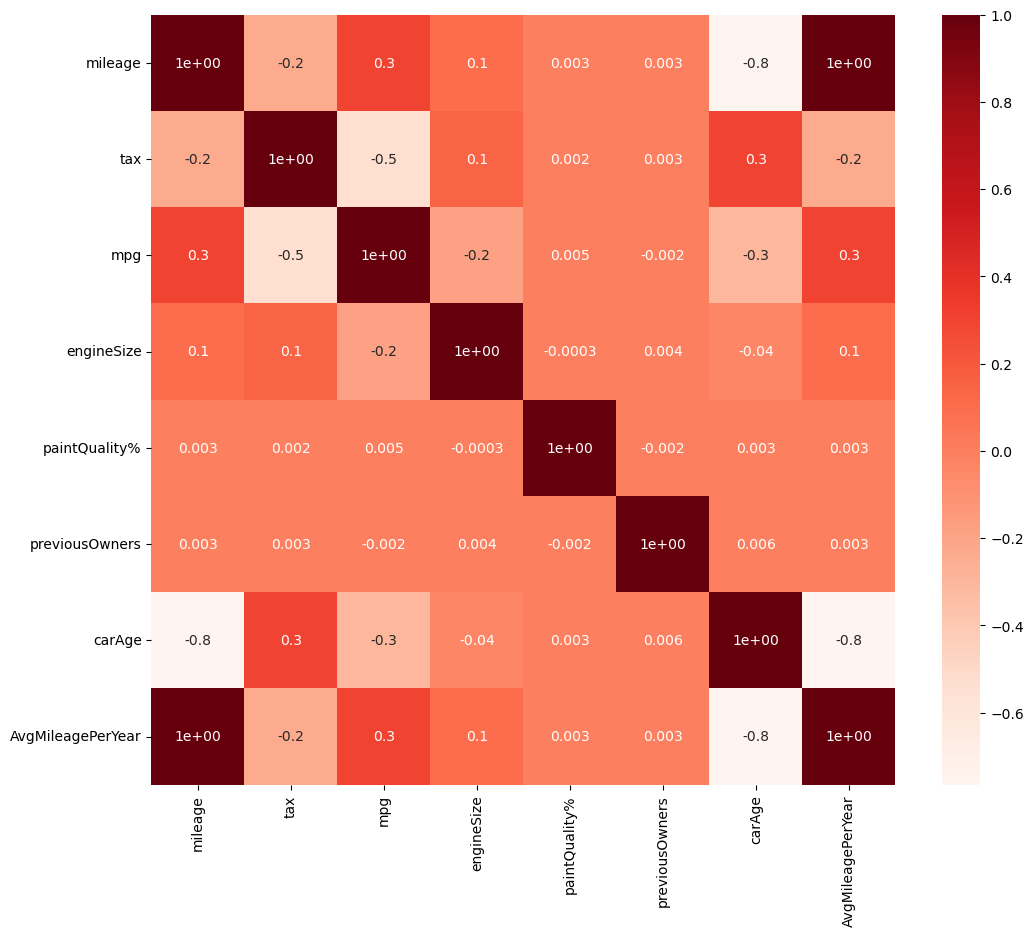

In [105]:
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show() 
cor_heatmap(cor_spearman)

Our correlation analysis revealed a significant multicollinearity issue between `carAge`-`mileage`, `carAge` - `AvgMileagePerYear` and `mileage` - `AvgMileagePerYear`. Specifically, the extremely strong correlation ($r = 1.0$) between `mileage` and `AvgMileagePerYear` indicates these features are perfectly redundant. Furthermore, the strong correlation between `carAge` and `mileage` ($r = -0.8$) suggests that keeping both could destabilize our linear model.

To resolve this, we evaluated the predictive strength of each feature against our target variable, `price`. The analysis showed that `carAge` has a substantially stronger correlation with `price` than `mileage` does. Consequently, we decided to drop both `mileage` and `AvgMileagePerYear`. By retaining only `carAge`, we build a more robust and interpretable model, as the essential predictive information is already captured by the car's age while avoiding the risks of multicollinearity.

#### 5.1.3 Chi-Square for categorical data

Finally, to complete the filter methods stage, the Chi-square test will be applied to the __categorical features__ to assess their relationship with the target variable. This test will help to identify which categorical variables have a significant association with `price`, allowing the selection of only the most relevant features for the next modeling steps.

In [106]:
def TestIndependence(var):
    dfObserved = pd.crosstab(y_train, X_train_cat[var])
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    return var if p >= 0.05 else None

unimportant_vars = Parallel(n_jobs=-1)(delayed(TestIndependence)(var) for var in X_train_cat.columns)
unimportant_vars = [v for v in unimportant_vars if v is not None]
print(unimportant_vars)

['Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes', 'Brand_volkswagen', 'model_200', 'model_220', 'model_230', 'model_3 series', 'model_6 series', 'model_7 series', 'model_8 series', 'model_a1', 'model_a3', 'model_a4', 'model_a5', 'model_a7', 'model_accent', 'model_amarok', 'model_ampera', 'model_antara', 'model_astra', 'model_avensis', 'model_b class', 'model_b-max', 'model_c class', 'model_caddy', 'model_caddy life', 'model_caddy maxi life', 'model_camry', 'model_caravelle', 'model_cascada', 'model_cc', 'model_citigo', 'model_clk', 'model_cls class', 'model_combo life', 'model_e class', 'model_ecosport', 'model_eos', 'model_fabia', 'model_fiesta', 'model_focus', 'model_fox', 'model_g class', 'model_galaxy', 'model_getz', 'model_gla class', 'model_glb class', 'model_gle class', 'model_golf', 'model_grand tourneo connect', 'model_hilux', 'model_i20', 'model_i3', 'model_i30', 'model_i40', 'model_i8', 'model_i800', 'model_insignia', 'model_ioniq', 'model_ix35', 'model_jetta', 

In [107]:
len(unimportant_vars)

128

According to __chi-square__, we should discard 128 columns.

### 5.2 Wrapper Methods

__Wrapper methods__ are a type of feature selection technique that use a machine learning model to evaluate how different sets of features affect prediction performance. Instead of relying only on statistics, these methods actually train and test the model multiple times to find the best combination of variables. Although this process takes more time, it often leads to better results. In this project, wrapper methods will be used to select the most important features for predicting price, starting with the __Recursive Feature Elimination (RFE)__ approach.

#### 5.2.1 RFE

This time, __Recursive Feature Elimination (RFE)__ will be applied. __RFE__ works by running multiple iterations of a predictive model, each time using a different subset of features. It begins with all available features and, at each step, removes the one considered the least important, repeating the process until a predefined number of features remains.

For __RFE__, any predictive algorithm capable of estimating feature importance can be used as the base estimator. In this case, a __Linear Regression__ model will serve as the base estimator for evaluating and ranking feature importance throughout the elimination process.

In [108]:
model = LinearRegression()

Using RFE, create a RFE instance called `rfe` and initialize by defining the following parameters:
- `estimator` = model
- `n_features_to_select` - We will have to check using a loop function.

In [109]:
nof_list = np.arange(1, len(X_train_num.columns)+1)
high_score = -np.inf
nof = 0
train_score_list = []
val_score_list = []
features_to_select = None

for n_features in nof_list:
    model = LinearRegression()
    rfe = RFE(estimator=model, n_features_to_select=n_features)
    
    X_train_rfe = rfe.fit_transform(X_train_num, y_train)
    model.fit(X_train_rfe, y_train)
    
    train_score = model.score(X_train_rfe, y_train)
    train_score_list.append(train_score)
    
    val_score = cross_val_score(model, X_train_rfe, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
    val_score_list.append(val_score)
    
    if val_score > high_score:
        high_score = val_score
        nof = n_features
        features_to_select = pd.Series(rfe.support_, index=X_train_num.columns)

print(f"Optimal number of features: {nof}")
print(f"Score with {nof} features: {high_score:.4f}")
print(f"Selected features: {features_to_select[features_to_select==True].index.tolist()}")


Optimal number of features: 7
Score with 7 features: 0.6832
Selected features: ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'carAge', 'AvgMileagePerYear']


Statistically, the best model after using this loop function had seven features: `mileage`, `tax`, `mpg`, `engineSize`, `paintQuality%`, `carAge`, and `AvgMileagePerYear`. However, as the purpose of the project is to predict the price without going to the mechanic, the `paintQuality%` feature does not make sense in the model because we cannot know the paint quality without going to the mechanic.

In [110]:
rfe = RFE(estimator = model, n_features_to_select = 7)

Transform the data using RFE by applying the method `fit_transform()` to the instance __RFE__, where __X__ should be assigned to your independent variables and __y__ to the dependent variable and assign it to the object `X_rfe`.

In [111]:
X_rfe = rfe.fit_transform(X=X_train_num, y=y_train)

Check the variables that were selected by RFE as the most "important" ones by calling the attribute `support_` to `rfe`.

In [112]:
X_train_num.columns

Index(['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners', 'carAge', 'AvgMileagePerYear'],
      dtype='object')

In [113]:
rfe.support_

array([ True,  True,  True,  True,  True, False,  True,  True])

Check the ranking of the variables defined by RFE as the most "important" ones by applying the attribute `ranking_` to `rfe`.

In [114]:
rfe.ranking_

array([1, 1, 1, 1, 1, 2, 1, 1])

Create an object (pandas Series) named `selected_features` that will have as index the `train_data_num` columns names and the `support_` attribute as value. <br>

In [115]:
selected_features = pd.Series(rfe.support_, index = X_train_num.columns)
selected_features

mileage               True
tax                   True
mpg                   True
engineSize            True
paintQuality%         True
previousOwners       False
carAge                True
AvgMileagePerYear     True
dtype: bool

Using this feature selection method, we would have kept seven features, which are: `mileage`, `tax`, `mpg`, `engineSize`, `paintQuality%`, `carAge` and `AvgMileagePerYear`.

### 5.3 Embedded Methods


__Embedded methods__ are a type of feature selection that incorporate the process of selecting important features directly into the training of a predictive model. Unlike __filter methods__, which rely on statistical measures, or __wrapper methods__, which repeatedly train models on different subsets, __embedded methods__ perform feature selection as part of the model fitting process. This makes them more efficient while still identifying the most relevant variables. In this project, __Lasso regression__ will be used as the embedded method to identify the features that contribute most to predicting price.

#### 5.3.1 Lasso Regression

To identify the most important features for predicting `price`, __Lasso regression (LassoCV)__ was applied to the numerical training data (`train_data_num`). __Lasso__ performs feature selection by shrinking less important feature coefficients to zero. After fitting the model, the coefficients were stored in a Pandas Series, allowing us to see which features were kept and which were eliminated.

In [116]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(8,10))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.show()

The `plot_importance()` function was then used to visualize the results. It sorts the coefficients, creates a horizontal bar plot, and adds a title indicating the model used. This provides a clear view of the features that contribute most to predicting price and illustrates how __Lasso__ effectively reduces dimensionality while retaining relevant variables.

In [117]:
reg = LassoCV()

In [118]:
reg.fit(X_train_num, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [119]:
coef = pd.Series(reg.coef_, index = X_train_num.columns)
coef

mileage             -10259.870555
tax                  -2543.352706
mpg                  -8256.518987
engineSize           22831.839264
paintQuality%          -67.560201
previousOwners          35.599107
carAge               17735.499046
AvgMileagePerYear       -0.000000
dtype: float64

In [120]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 7 variables and eliminated the other 1 variables


In [121]:
coef.sort_values()

mileage             -10259.870555
mpg                  -8256.518987
tax                  -2543.352706
paintQuality%          -67.560201
AvgMileagePerYear       -0.000000
previousOwners          35.599107
carAge               17735.499046
engineSize           22831.839264
dtype: float64

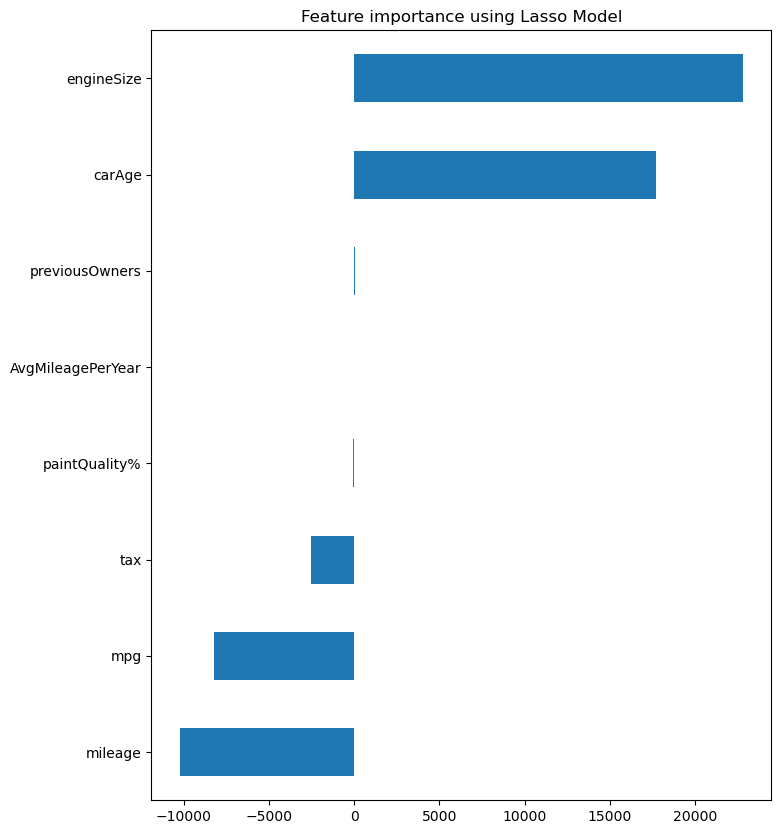

In [122]:
plot_importance(coef,'Lasso')

__Lasso regression__ retained 7 features and discarding 1, indicating that each variable provides useful information for predicting `price`. The `plot_importance()` visualization confirms the relative contribution of each feature, showing that all were considered relevant by the model.

### 5.4 Final Insights

##### 5.4.1 Numerical Data

| Predictor | Univariate |Spearman | RFE SVM | Lasso | What to do? (One possible way to "solve") | 
| --- | --- | --- | --- |--- |---|
| 'mileage'| Keep |Discard | Keep |Keep | Try with and without |
| 'tax' | Keep| Keep | Keep |Keep | Include in the model |
| 'mpg' | Keep |Keep | Keep | Keep | Include in the model |
| 'engineSize' | Keep |Keep | Keep | Keep | Include in the model|
| 'paintQuality%' | Keep |Keep | Keep | Keep | Include in the model |
| 'previousOwners' | Keep |Keep |Discard | Keep |  Try with and without |
| 'carAge' |Keep |Keep |Keep |Keep | Include in the model|
| 'AvgMileagePerYear' |Keep |Discard |Keep |Discard | Try with and without|


In conclusion, we will remove the `paintQuality%` feature from all our models, as it does not serve the purpose of the project. Statistically, all models indicated that the `paintQuality%` feature should be kept. While this may be statistically correct, according to the project's objective, it does not make sense to keep it because customers would need to visit a mechanic to obtain this information and the goal is to predict car prices without moving there.


##### 5.4.2 Categorical Data
For the categorical data, with the method `chi-square`, statisticaly, it was recommended to discard 128 columns: <br>
<br>
'Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes', 'Brand_volkswagen', 'model_200', 'model_220', 'model_230', 'model_3 series', 'model_6 series', 'model_7 series', 'model_8 series', 'model_a1', 'model_a3', 'model_a4', 'model_a5', 'model_a7', 'model_accent', 'model_amarok', 'model_ampera', 'model_antara', 'model_astra', 'model_avensis', 'model_b class', 'model_b-max', 'model_c class', 'model_caddy', 'model_caddy life', 'model_caddy maxi life', 'model_camry', 'model_caravelle', 'model_cascada', 'model_cc', 'model_citigo', 'model_clk', 'model_cls class', 'model_combo life', 'model_e class', 'model_ecosport', 'model_eos', 'model_fabia', 'model_fiesta', 'model_focus', 'model_fox', 'model_g class', 'model_galaxy', 'model_getz', 'model_gla class', 'model_glb class', 'model_gle class', 'model_golf', 'model_grand tourneo connect', 'model_hilux', 'model_i20', 'model_i3', 'model_i30', 'model_i40', 'model_i8', 'model_i800', 'model_insignia', 'model_ioniq', 'model_ix35', 'model_jetta', 'model_ka', 'model_kamiq', 'model_karoq', 'model_kodiaq', 'model_kona', 'model_kuga', 'model_land cruiser', 'model_m2', 'model_m3', 'model_m4', 'model_m5', 'model_m6', 'model_mustang', 'model_passat', 'model_polo', 'model_puma', 'model_q2', 'model_q3', 'model_q5', 'model_q7', 'model_q8', 'model_ranger', 'model_rapid', 'model_roomster', 'model_rs5', 'model_s-max', 'model_s3', 'model_s8', 'model_santa fe', 'model_scirocco', 'model_sharan', 'model_sq5', 'model_sq7', 'model_streetka', 'model_supra', 'model_t-cross', 'model_terracan', 'model_tigra', 'model_tiguan', 'model_tiguan allspace', 'model_tourneo custom', 'model_tt', 'model_tucson', 'model_unknown', 'model_up', 'model_urban cruiser', 'model_v class', 'model_vectra', 'model_veloster', 'model_verso', 'model_viva', 'model_vivaro', 'model_x1', 'model_x2', 'model_x6', 'model_yeti outdoor', 'model_z3', 'model_zafira', 'model_zafira tourer', 'transmission_manual', 'transmission_semi-auto', 'transmission_unknown', 'fuelType_electric', 'fuelType_petrol', 'fuelType_unknown'

In [123]:
X_test = pd.concat([test_data_real, test_data_num, test_data_cat], axis=1)

In [124]:
X_test

,carID,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,Brand_opel,Brand_skoda,Brand_toyota,Brand_volkswagen,model_2 series,model_200,model_220,model_230,model_3 series,model_4 series,model_5 series,model_6 series,model_7 series,model_8 series,model_a class,model_a1,model_a3,model_a4,model_a5,model_a6,model_a7,model_a8,model_accent,model_adam,model_agila,model_amarok,model_ampera,model_antara,model_arteon,model_astra,model_auris,model_avensis,model_aygo,model_b class,model_b-max,model_beetle,model_c class,model_c-hr,model_c-max,model_caddy,model_caddy life,model_caddy maxi,model_caddy maxi life,model_california,model_camry,model_caravelle,model_cascada,model_cc,model_citigo,model_cl class,model_cla class,model_clc class,model_clk,model_cls class,model_combo life,model_corolla,model_corsa,model_crossland x,model_e class,model_ecosport,model_edge,model_eos,model_fabia,model_fiesta,model_focus,model_fox,model_fusion,model_g class,model_galaxy,model_getz,model_gl class,model_gla class,model_glb class,model_glc class,model_gle class,model_gls class,model_golf,model_grand c-max,model_grand tourneo connect,model_grandland x,model_gt86,model_gtc,model_hilux,model_i10,model_i20,model_i3,model_i30,model_i40,model_i8,model_i800,model_insignia,model_ioniq,model_iq,model_ix20,model_ix35,model_jetta,model_ka,model_ka+,model_kadjar,model_kamiq,model_karoq,model_kodiaq,model_kona,model_kuga,model_land cruiser,model_m class,model_m2,model_m3,model_m4,model_m5,model_m6,model_meriva,model_mokka,model_mondeo,model_mustang,model_octavia,model_passat,model_polo,model_prius,model_proace verso,model_puma,model_q2,model_q3,model_q5,model_q7,model_q8,model_r8,model_ranger,model_rapid,model_rav4,model_roomster,model_rs3,model_rs4,model_rs5,model_rs6,model_s-max,model_s3,model_s4,model_s5,model_s8,model_santa fe,model_scala,model_scirocco,model_sharan,model_shuttle,model_sl class,model_slk,model_sq5,model_sq7,model_streetka,model_superb,model_supra,model_t-cross,model_t-roc,model_terracan,model_tigra,model_tiguan,model_tiguan allspace,model_touareg,model_touran,model_tourneo connect,model_tourneo custom,model_tt,model_tucson,model_unknown,model_up,model_urban cruiser,model_v class,model_vectra,model_veloster,model_verso,model_viva,model_vivaro,model_x-class,model_x1,model_x2,model_x3,model_x4,model_x5,model_x6,model_x7,model_yaris,model_yeti,model_yeti outdoor,model_z3,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,89856,0.314517,0.683333,0.223881,0.30,0.449275,0.75,1.000000,3.128041e-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,106581,0.000000,0.500000,0.169154,0.50,0.434783,0.50,0.727273,1.515971e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [125]:
# Save X_train
X_train_scaled.to_csv("../Group_28/project_data/X_train.csv", index=False, encoding='utf-8')

# Save X_val
X_val_scaled.to_csv("../Group_28/project_data/X_val.csv", index=False, encoding='utf-8')

# Save y_train
y_train.to_csv("../Group_28/project_data/y_train.csv", index=False, encoding='utf-8')

# save y_val
y_val.to_csv("../Group_28/project_data/y_val.csv", index=False, encoding='utf-8')

#save test_data
test_data.to_csv("../Group_28/project_data/test_data.csv", index=False, encoding='utf-8')

## 6. Model Selection

According to what we learned in class, we should use the holdout method in this case. Although __Leave-One-Out Cross Validation__ would probably produce more reliable results, it is very __time-consuming and should only be used when the dataset is small__, which is not the case here.
For that reason, we will predict the values `y_val` using `.predict()`.

Before training, we will create the final DataFrames based on your feature selection.

 We will start by removing every feature that was recommended for removal by at least one model.

We decided to keep the 128 categorical features that were supposed to be discarded in all models, because we thought that the model and brand of a car are important features. Every car has its price: for example, a Mercedes is more expensive than a Renault, while a BMW Series 1 is cheaper than a BMW Series 3. 

That's why we tested the categorical features on the model. 

The exact opposite happens with the feature `paintQuality%`, because this feature can only be obtained by going to the mechanic, which contradicts the purpose of this project, which is to predict the price before going to the mechanic.

Statistically, it was meant to be kept, but it is not correct for the purpose of the project.

### 6.1 Testing models - removing 3 numerical features

We'll start by removing `paintQuality%`, `previousOwners` and `AvgMileagePerYear`.

In [126]:
features_to_remove = []

In [127]:
features_to_remove.append('paintQuality%')
features_to_remove.append('previousOwners')
features_to_remove.append('AvgMileagePerYear')
features_to_remove.append('mileage')

In [128]:
X_train = X_train_scaled.drop(columns=features_to_remove)

In [129]:
X_val = X_val_scaled.drop(columns=features_to_remove)

We applied a logarithmic transformation ($log1p$) to the target variable to normalize its distribution and prevent the model from predicting impossible negative prices. This transformation stabilizes the variance and allows the model to better capture relative price fluctuations, resulting in a more robust and accurate forecasting tool.

To ensure the final results were interpretable, we performed an inverse transformation to return the predictions to their original monetary scale.

In [130]:
y_train_log = np.log1p(y_train) 

In [131]:
# 1. Instantiate the Linear Regression Model
lr_model = LinearRegression()

In [132]:
# 2. Training the Model
lr_model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [133]:
y_preds_log_train = lr_model.predict(X_train)

In [134]:
y_preds_log_val = lr_model.predict(X_val)

In [135]:
y_preds_1_train= np.expm1(y_preds_log_train)
y_preds_1_val= np.expm1(y_preds_log_val)

In [136]:
# 5. Evaluate the performance for the training data set

mae_train_real = mean_absolute_error(y_train, y_preds_1_train)
print(f"MAE (Mean Absolute Error): {mae_train_real:.2f}")

r2 = r2_score(y_train, y_preds_1_train)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_train, y_preds_1_train))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 2092.90
R² (R-squared): 0.8589
RMSE (Root Mean Squared Error): 3634.7343


In [137]:
# 5. Evaluate the performance for the validation data set

mae_val_real = mean_absolute_error(y_val, y_preds_1_val)
print(f"MAE (Mean Absolute Error): {mae_val_real:.2f}")

r2 = r2_score(y_val, y_preds_1_val)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_val, y_preds_1_val))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 2083.78
R² (R-squared): 0.8659
RMSE (Root Mean Squared Error): 3615.9458


The model is well fitted and generalizes excellently, evidenced by the nearly identical $R^2$ scores  of $0.88$ and error metrics across both training and validation sets, which effectively rules out overfitting. It captures about $89\%$ of the data's variance, showing strong predictive power, but the significant gap between the $RMSE$ ($3384.44$) and $MAE$ ($1894.38$) indicates the presence of outliers, suggesting that while the model is generally consistent, it occasionally makes large errors on specific data points.

In [138]:
X_test = test_data_scaled.drop(columns=features_to_remove)

In [139]:
X_test_log = np.log1p(X_test)

In [140]:
y_preds_log_test = lr_model.predict(X_test_log)

In [141]:
y_preds_1_test= np.expm1(y_preds_log_test)
print(y_preds_1_test)

[13422.52762512 15631.82850285 11412.95958233 ... 20321.99006139
 14717.19250301  9138.36731908]


### 6.2 Testing models - removing 2 numerical features

Now, we will remove these features: `paintQuality%` and `previousOwners`.


We are going to test if we need to discard `previousOwners` as was concluded by the RFE SVM method.

In [142]:
features_to_remove = []

In [143]:
features_to_remove.append('paintQuality%')
features_to_remove.append('previousOwners')

In [144]:
X_train = X_train_scaled.drop(columns=features_to_remove)

In [145]:
X_val = X_val_scaled.drop(columns=features_to_remove)

We applied a logarithmic transformation ($log1p$) to the target variable to normalize its distribution and prevent the model from predicting impossible negative prices. This transformation stabilizes the variance and allows the model to better capture relative price fluctuations, resulting in a more robust and accurate forecasting tool.

To ensure the final results were interpretable, we performed an inverse transformation to return the predictions to their original monetary scale.

In [146]:
y_train_log = np.log1p(y_train)

In [147]:
lr_model = LinearRegression()

In [148]:
lr_model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [149]:
y_preds_log_train = lr_model.predict(X_train)

In [150]:
y_preds_log_val = lr_model.predict(X_val)

In [151]:
y_preds_2_train= np.expm1(y_preds_log_train)
y_preds_2_val= np.expm1(y_preds_log_val)

In [152]:
# 5. Evaluate the performance fro the traning data set

mae_train_real = mean_absolute_error(y_train, y_preds_2_train)
print(f"MAE (Mean Absolute Error): {mae_train_real:.2f}")

r2 = r2_score(y_train, y_preds_2_train)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_train, y_preds_2_train))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1914.05
R² (R-squared): 0.8767
RMSE (Root Mean Squared Error): 3398.4216


In [153]:
# 5. Evaluate the performance fro the validation  data set

mae_val_real = mean_absolute_error(y_val, y_preds_2_val)
print(f"MAE (Mean Absolute Error): {mae_val_real:.2f}")

r2 = r2_score(y_val, y_preds_2_val)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_val, y_preds_2_val))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1991.59
R² (R-squared): 0.8758
RMSE (Root Mean Squared Error): 3480.2328


This model demonstrates solid generalization with no signs of overfitting, as the training $R^2$ of $0.88$ and validation R^2 (0.88) are nearly identical. It successfully explains roughly 89\% of the variance in the data, but the performance is marginally lower than the previous model. The significant gap between the $MAE$ ($1991.59$) and the much higher $RMSE$ ($34.80.2328$) suggests that outliers or large errors on specific predictions are still heavily influencing the final score.

In [154]:
X_test = test_data_scaled.drop(columns=features_to_remove)

In [155]:
X_test_log = np.log1p(X_test)

In [156]:
y_preds_log_test = lr_model.predict(X_test_log)

In [157]:
y_preds_2_test = np.expm1(y_preds_log_test)
print(y_preds_2_test)

[14016.73830596 20244.03063889 12438.73411982 ... 24451.32789372
 18302.47048751 10966.94252073]


### 6.3 Testing Models - removing (other) 2 numerical features

We are going to remove these features: `paintQuality%` and `AvgMileagePerYear`.

In [158]:
features_to_remove = []

In [159]:
features_to_remove.append('paintQuality%')
features_to_remove.append('AvgMileagePerYear')

In [160]:
X_train = X_train_scaled.drop(columns=features_to_remove)

In [161]:
X_val = X_val_scaled.drop(columns=features_to_remove)

We applied a logarithmic transformation ($log1p$) to the target variable to normalize its distribution and prevent the model from predicting impossible negative prices. This transformation stabilizes the variance and allows the model to better capture relative price fluctuations, resulting in a more robust and accurate forecasting tool.

To ensure the final results were interpretable, we performed an inverse transformation to return the predictions to their original monetary scale.

In [162]:
y_train_log = np.log1p(y_train)

In [163]:
lr_model = LinearRegression()

In [164]:
lr_model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [165]:
y_preds_log_train = lr_model.predict(X_train)

In [166]:
y_preds_log_val = lr_model.predict(X_val)

In [167]:
y_preds_3_train= np.expm1(y_preds_log_train)
y_preds_3_val= np.expm1(y_preds_log_val)

In [168]:
# 5. Evaluate the performance for the train data set

mae_train_real = mean_absolute_error(y_train, y_preds_3_train)
print(f"MAE (Mean Absolute Error): {mae_train_real:.2f}")

r2 = r2_score(y_train, y_preds_3_train)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_train, y_preds_3_train))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1899.98
R² (R-squared): 0.8779
RMSE (Root Mean Squared Error): 3381.5931


In [169]:
# 5. Evaluate the performance for the validation data set

mae_val_real = mean_absolute_error(y_val, y_preds_3_val)
print(f"MAE (Mean Absolute Error): {mae_val_real:.2f}")

r2 = r2_score(y_val, y_preds_3_val)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_val, y_preds_3_val))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1894.40
R² (R-squared): 0.8825
RMSE (Root Mean Squared Error): 3384.5502


This model effectively corrects the issues seen in the previous step, returning to a very stable and well-generalized state. The training $R^2$ of $0.8779$ and validation $R^2$ of $0.8825$ are extremely close, indicating almost no overfitting. The error metrics also stabilized, with an $MAE$ of $1894.40$ and an $RMSE$ of $3384.55$, essentially replicating the strong performance of the very first model but with slightly tighter training alignment.

In [170]:
X_test = test_data_scaled.drop(columns=features_to_remove)
X_test_log = np.log1p(X_test)
y_preds_log_test = lr_model.predict(X_test_log)
y_preds_3_test = np.expm1(y_preds_log_test)
print(y_preds_3_test)

[12997.27103074 19358.80245245 11894.43387485 ... 23344.58718581
 17333.99897254 10556.68945602]


### 6.4 Testing models - removing 1 numerical feature

So, now we are just removing `paintQuality%`, as we concluded earlier, this feature can only be evaluated in the mechanic itself, which is not the objective of this project.

In [171]:
features_to_remove = []

In [172]:
features_to_remove.append('paintQuality%')

In [173]:
X_train = X_train_scaled.drop(columns=features_to_remove)

In [174]:
X_val = X_val_scaled.drop(columns=features_to_remove)

We applied a logarithmic transformation ($log1p$) to the target variable to normalize its distribution and prevent the model from predicting impossible negative prices. This transformation stabilizes the variance and allows the model to better capture relative price fluctuations, resulting in a more robust and accurate forecasting tool.

To ensure the final results were interpretable, we performed an inverse transformation to return the predictions to their original monetary scale.

In [175]:
y_train_log = np.log1p(y_train)

In [176]:
lr_model = LinearRegression()

In [177]:
lr_model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [178]:
y_preds_log_train = lr_model.predict(X_train)
y_preds_log_val = lr_model.predict(X_val)

In [179]:
y_preds_4_train= np.expm1(y_preds_log_train)
y_preds_4_val= np.expm1(y_preds_log_val)

In [180]:
# 5. Evaluate the performance for the train data set

mae_train_real = mean_absolute_error(y_train, y_preds_4_train)
print(f"MAE (Mean Absolute Error): {mae_train_real:.2f}")

r2 = r2_score(y_train, y_preds_4_train)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_train, y_preds_4_train))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1914.00
R² (R-squared): 0.8767
RMSE (Root Mean Squared Error): 3398.4037


In [181]:
# 5. Evaluate the performance for the validation data set

mae_val_real = mean_absolute_error(y_val, y_preds_4_val)
print(f"MAE (Mean Absolute Error): {mae_val_real:.2f}")

r2 = r2_score(y_val, y_preds_4_val)
print(f"R² (R-squared): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_val, y_preds_4_val))
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

MAE (Mean Absolute Error): 1991.63
R² (R-squared): 0.8758
RMSE (Root Mean Squared Error): 3480.3375


This model demonstrates strong predictive capability, explaining roughly nearly $88\%$ of the data's variance with a training $R^2$ of $0.8767$ and a validation $R^2$ of $0.8758$. It generalizes reasonably well, showing only a minor performance drop on unseen data, though the validation $MAE$ of $1991.63$ confirms it is slightly less precise outside the training set. The substantial difference between the MAE and the significantly higher $RMSE$ of  $3480.34$ indicates that while the average prediction is solid, the model is still penalized heavily by large errors on specific outlier data points.

In [182]:
X_test = test_data_scaled.drop(columns=features_to_remove)
X_test_log = np.log1p(X_test)
y_preds_log_test = lr_model.predict(X_test_log)
y_preds_4_test = np.expm1(y_preds_log_test)
print(y_preds_4_test)

[14017.50934753 20241.35678722 12437.01216574 ... 24457.64594918
 18295.35523395 10970.05443798]


### 7. Conclusions - Best Model


| __Metric__ | __Model 1__ | __Model 2__ | __Model 3__ | __Model 4__ |  
| --------- | ------------- | ------------- | ------ | ----------- |
| Train $MAE$ | 1900.05| 1914.05 | 1899.98 | 1914.00 |  
| Train $R²$ | 0.8779 | 0.8767 | 0.8779 | 0.8767 |  
| Train $RMSE$ | 3381.60 | 3398.42 | 3381.59 | 3398.40 |  
| Val $MAE$ | 1894.38| 1991.59| 1894.40 | 1991.63 |  
| Val $R²$ | 0.8825 | 0.8758 | 0.8825 | 0.8758 |  
| Val $RMSE$ |3384.44 | 3480.23 | 3384.5502 | 3480.34 |  


After analyzing all four models, it is clear that the best-performing models, with results closely aligned and the highest validation $R^2$ value of 0.8825 and lowest error values, are Model 1 and Model 3. On the other hand, the obvious regression in performance of Models 2 & 4, with lower validation values of 0.8758 and higher values of errors ($MAE/RMSE$), reveals them to be less capable of making predictions on new, unseen data. As such, the best model is therefore Model 1, outperforming Model 3 by a negligible margin with the lowest value of Validation MAE of 1894.38 & Validation $RMSE$ of 3384.44.


In conclusion, we will test other predictive models in the next notebook and then compare the best model from each notebook.

### 8. Test Prediction and creation of a CSV file

In [183]:
print(y_preds_1_test.shape)

(32567,)


In [184]:
submission_results = pd.DataFrame(y_preds_1_test, columns=['price'], index=test_data_indexed.index)

submission_results = submission_results.reset_index()
submission_results.columns = ['carID', 'price']
submission_results.to_csv('Group_28_Version25.csv', index=False)
print(submission_results.head())

    carID         price
0   89856  13422.527625
1  106581  15631.828503
2   80886  11412.959582
3  100174  12545.686498
4   81376  14846.502615
